# PDE Model Reconstruction: POD-SVD, POD-rSVD, POD-DEIM, and POD-rSVD-DEIM

This notebook implements the experimental analysis for Section 4 of the report: **PDE Model Reconstruction**.

We compare four reduced-order modelling strategies for nonlinear PDEs:

- **POD-SVD**: POD basis computed with classical deterministic SVD;
- **POD-rSVD**: POD basis computed with randomized SVD;
- **POD-DEIM**: nonlinear DEIM basis computed with classical deterministic SVD;
- **POD-rSVD-DEIM**: DEIM basis computed with randomized SVD.

The key conceptual distinction is that randomized SVD and DEIM accelerate different stages of the reduced-order pipeline.
Randomized SVD accelerates the construction of low-dimensional bases, while DEIM accelerates nonlinear term evaluation. Therefore, they can be naturally combined.

The two model problems are:

1. **Allen-Cahn equation**, from the lab exercise:
$$
y_t - \alpha \Delta y - \mu (y-y^3)=0,
\qquad \Omega=[0,1]^2.
$$

2. **Nonlinear steady-state elliptic problem**, from Chaturantabut and Sorensen:
$$
-\nabla^2 u(x,y)+s(u(x,y);\mu)=100\sin(2\pi x)\sin(2\pi y),
$$
with
$$
s(u;\mu)=\frac{\mu_1}{\mu_2}\left(e^{\mu_2 u}-1\right).
$$

References used in the report:

- Halko, Martinsson, and Tropp, *Finding Structure with Randomness*, SIAM Review, 2011.
- Chaturantabut and Sorensen, *Nonlinear Model Reduction via Discrete Empirical Interpolation*, SIAM Journal on Scientific Computing, 2010.
- Quarteroni, Manzoni, and Negri, *Reduced Basis Methods for Partial Differential Equations*, Springer, 2015.


## 1. Imports and global settings

The notebook is designed for Google Colab and uses only standard scientific Python packages.
No external data files are required.

In [40]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import time
import os
import re
import zipfile
from dataclasses import dataclass

try:
    from sklearn.utils.extmath import randomized_svd
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

np.random.seed(42)

# SVD backend choices.
# "svds" computes only the requested factors; "svd" computes the dense SVD.
SVD_MODE = "svds"
RSVD_INNER_SVD_MODE = "svd"

# Repeat each timed basis construction and report average execution time.
N_EXPERIMENT_REPEATS = 10

# Thesis-quality plotting defaults.
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "figure.titlesize": 18,
    "axes.linewidth": 1.1,
    "lines.linewidth": 2.4,
    "lines.markersize": 7,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

FIGURE_DIR = "thesis_figures"
os.makedirs(FIGURE_DIR, exist_ok=True)


## 2. Utility functions

This section defines:

- a 2D finite-difference Laplacian with homogeneous Dirichlet boundary conditions;
- classical POD basis construction;
- randomized POD basis construction;
- DEIM interpolation point selection;
- relative error and timing utilities.

For all experiments, the solution is represented only at interior grid points.
If the spatial grid has `n` interior points per direction, the full-order dimension is:

\[
N=n^2.
\]

In [41]:
def make_laplacian_2d(n):
    """
    Construct the 2D finite-difference Laplacian on (0,1)^2
    with homogeneous Dirichlet boundary conditions.

    Parameters
    ----------
    n : int
        Number of interior grid points per spatial direction.

    Returns
    -------
    L : scipy.sparse.csr_matrix
        Sparse matrix approximating the Laplacian operator Delta.
    h : float
        Spatial grid size.
    X, Y : ndarray
        Meshgrid of interior points.
    """
    h = 1.0 / (n + 1)
    x = np.linspace(h, 1.0 - h, n)
    X, Y = np.meshgrid(x, x, indexing="ij")

    e = np.ones(n)
    T = sp.diags([e, -2.0 * e, e], [-1, 0, 1], shape=(n, n), format="csr") / h**2
    I = sp.eye(n, format="csr")
    L = sp.kron(I, T) + sp.kron(T, I)
    return L.tocsr(), h, X, Y


def relative_fro_error(A, Ahat):
    """Relative Frobenius norm error."""
    return la.norm(A - Ahat, ord="fro") / la.norm(A, ord="fro")


def relative_l2_error(u, uhat):
    """Relative Euclidean norm error."""
    return la.norm(u - uhat) / la.norm(u)


def _leading_svd(A, k, mode="svd"):
    """Return leading k singular triplets using the selected backend."""
    min_dim = min(A.shape)

    if mode == "svds" and k < min_dim:
        U, s, Vt = spla.svds(A, k=k, which="LM")
        order = np.argsort(s)[::-1]
        return U[:, order], s[order], Vt[order, :]

    U, s, Vt = la.svd(A, full_matrices=False)
    return U[:, :k], s[:k], Vt[:k, :]


def pod_basis_svd(S, r, mode="svd"):
    """
    Construct a POD basis from a snapshot matrix using classical SVD.

    S has shape (N, Ns), where N is the full-order dimension
    and Ns is the number of snapshots.
    """
    t0 = time.perf_counter()
    U, s, Vt = _leading_svd(S, r, mode=mode)
    elapsed = time.perf_counter() - t0
    Phi = U[:, :r]
    return Phi, s, elapsed


def pod_basis_rsvd(S, r, oversampling=10, n_iter=1, random_state=42, inner_svd_mode="svd"):
    """
    Construct a POD basis from a snapshot matrix using randomized SVD.
    """
    rng = np.random.default_rng(random_state)
    n_columns = S.shape[1]
    ell = min(r + oversampling, min(S.shape))

    t0 = time.perf_counter()

    Omega = rng.standard_normal(size=(n_columns, ell))
    Y = S @ Omega

    for _ in range(n_iter):
        Y = S @ (S.T @ Y)

    Q, _ = la.qr(Y, mode="economic")
    B = Q.T @ S
    U_tilde, s, Vt = _leading_svd(B, r, mode=inner_svd_mode)
    U = Q @ U_tilde

    elapsed = time.perf_counter() - t0
    return U[:, :r], s, elapsed


def projection_reconstruction_error(S, Phi):
    """
    Compute the relative reconstruction error of the snapshot matrix
    using the orthogonal projection onto span(Phi).
    """
    Shat = Phi @ (Phi.T @ S)
    return relative_fro_error(S, Shat)


def deim(U):
    """
    Classical DEIM index selection.

    Given a nonlinear basis U = [u_1, ..., u_m], select interpolation indices
    following the greedy DEIM algorithm.
    """
    n, m = U.shape
    indices = []

    p0 = np.argmax(np.abs(U[:, 0]))
    indices.append(p0)

    for j in range(1, m):
        U_prev = U[:, :j]
        p_prev = np.array(indices)

        c = la.solve(U_prev[p_prev, :], U[p_prev, j])
        r = U[:, j] - U_prev @ c
        pj = np.argmax(np.abs(r))
        indices.append(pj)

    return np.array(indices, dtype=int)


def deim_approximation(f, U_f, indices):
    """
    Evaluate the DEIM approximation of a nonlinear vector f.

    f approximately equals U_f (P^T U_f)^(-1) P^T f.
    """
    PTUf = U_f[indices, :]
    coeff = la.solve(PTUf, f[indices])
    return U_f @ coeff


def time_function(func, n_repeats=5):
    """Measure average wall-clock execution time of a function."""
    times = []
    out = None
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        out = func()
        times.append(time.perf_counter() - t0)
    return out, np.mean(times), np.std(times)


def effective_rank_from_snapshots(S, requested_rank):
    """
    Return a safe rank for SVD/rSVD computations.
    The maximum numerical rank cannot exceed min(S.shape).
    """
    return int(max(1, min(requested_rank, min(S.shape))))


def pod_basis(
    S,
    r,
    method="svd",
    oversampling=10,
    n_iter=1,
    random_state=42,
    svd_mode=None,
    rsvd_inner_svd_mode=None,
    n_repeats=1,
):
    """
    Unified POD basis constructor.

    Parameters
    ----------
    S : ndarray
        Snapshot matrix.
    r : int
        Requested reduced dimension.
    method : {'svd', 'rsvd'}
        Basis construction method.
    oversampling : int
        Oversampling parameter for rSVD.
    n_iter : int
        Number of power iterations for rSVD.
    random_state : int
        Random seed for reproducibility.
    svd_mode : {'svd', 'svds'}
        SVD backend for deterministic POD.
    rsvd_inner_svd_mode : {'svd', 'svds'}
        SVD backend for the small projected matrix in rSVD.
    n_repeats : int
        Number of repeated timings to average.
    """
    svd_mode = SVD_MODE if svd_mode is None else svd_mode
    rsvd_inner_svd_mode = RSVD_INNER_SVD_MODE if rsvd_inner_svd_mode is None else rsvd_inner_svd_mode

    if svd_mode not in {"svd", "svds"}:
        raise ValueError("svd_mode must be either 'svd' or 'svds'.")
    if rsvd_inner_svd_mode not in {"svd", "svds"}:
        raise ValueError("rsvd_inner_svd_mode must be either 'svd' or 'svds'.")
    if n_repeats < 1:
        raise ValueError("n_repeats must be at least 1.")

    r_eff = effective_rank_from_snapshots(S, r)
    times = []
    Phi = s = info = None

    for repeat in range(n_repeats):
        if method == "svd":
            Phi, s, elapsed = pod_basis_svd(S, r_eff, mode=svd_mode)
            info = {"r_eff": r_eff, "p_eff": None}
        elif method == "rsvd":
            max_p = max(0, min(S.shape) - r_eff)
            p_eff = int(min(max(0, oversampling), max_p))
            Phi, s, elapsed = pod_basis_rsvd(
                S,
                r_eff,
                oversampling=p_eff,
                n_iter=n_iter,
                random_state=random_state,
                inner_svd_mode=rsvd_inner_svd_mode,
            )
            info = {"r_eff": r_eff, "p_eff": p_eff}
        else:
            raise ValueError("method must be either 'svd' or 'rsvd'")

        times.append(elapsed)

    info["time_std"] = float(np.std(times))
    return Phi, s, float(np.mean(times)), info


def deim_analysis(
    F_train,
    S_test,
    nonlinear_function,
    m_values,
    basis_method="svd",
    oversampling=10,
    n_iter=1,
    random_state=42,
    n_repeats=5,
    n_basis_repeats=None,
    svd_mode=None,
    rsvd_inner_svd_mode=None,
):
    """
    Build a DEIM basis either with classical SVD or randomized SVD and
    evaluate the nonlinear approximation error and timing on test snapshots.

    Parameters
    ----------
    F_train : ndarray
        Nonlinear snapshot matrix used to build the DEIM basis.
    S_test : ndarray
        State snapshots used to evaluate the nonlinear function.
    nonlinear_function : callable
        Function taking a state vector and returning the nonlinear vector.
    m_values : list[int]
        DEIM basis dimensions.
    basis_method : {'svd', 'rsvd'}
        Method used to compute the nonlinear basis U_f.
    oversampling : int
        rSVD oversampling parameter when basis_method='rsvd'.
    n_iter : int
        rSVD power iterations when basis_method='rsvd'.
    random_state : int
        Random seed.
    n_repeats : int
        Number of repetitions used for wall-clock timing of evaluations.
    n_basis_repeats : int
        Number of repetitions used for wall-clock timing of basis construction.
    """
    results = []
    if n_basis_repeats is None:
        n_basis_repeats = N_EXPERIMENT_REPEATS

    for m in m_values:
        U_f, sf, build_time, info = pod_basis(
            F_train,
            m,
            method=basis_method,
            oversampling=oversampling,
            n_iter=n_iter,
            random_state=random_state,
            svd_mode=svd_mode,
            rsvd_inner_svd_mode=rsvd_inner_svd_mode,
            n_repeats=n_basis_repeats,
        )
        m_eff = info["r_eff"]
        indices = deim(U_f)

        errors = []
        full_times = []
        deim_times = []

        for j in range(S_test.shape[1]):
            y = S_test[:, j]
            f_true = nonlinear_function(y)

            _, full_t, _ = time_function(lambda: nonlinear_function(y), n_repeats=n_repeats)
            f_deim, deim_t, _ = time_function(lambda: deim_approximation(f_true, U_f, indices), n_repeats=n_repeats)

            denom = la.norm(f_true)
            if denom == 0:
                errors.append(0.0)
            else:
                errors.append(la.norm(f_true - f_deim) / denom)
            full_times.append(full_t)
            deim_times.append(deim_t)

        label = "POD-DEIM" if basis_method == "svd" else f"p={oversampling}, q={n_iter}"
        results.append({
            "method": label,
            "basis_method": basis_method,
            "m": m_eff,
            "p": None if basis_method == "svd" else oversampling,
            "p_eff": info["p_eff"],
            "q": None if basis_method == "svd" else n_iter,
            "basis_time": float(build_time),
            "basis_time_std": info["time_std"],
            "mean_error": float(np.mean(errors)),
            "std_error": float(np.std(errors)),
            "full_time": float(np.mean(full_times)),
            "deim_time": float(np.mean(deim_times)),
            "speedup": float(np.mean(full_times) / np.mean(deim_times)) if np.mean(deim_times) > 0 else np.inf,
            "n_deim_points": int(len(indices)),
        })

    return results


def plot_deim_comparison(results, title_prefix):
    """
    Plot DEIM and rSVD-DEIM nonlinear approximation error, basis construction time,
    and evaluation time.
    """
    methods = []
    for row in results:
        if row["method"] not in methods:
            methods.append(row["method"])

    fig, ax = plt.subplots(figsize=(9, 5))
    for method in methods:
        rows = [x for x in results if x["method"] == method]
        ax.errorbar(
            [x["m"] for x in rows],
            [x["mean_error"] for x in rows],
            yerr=[x["std_error"] for x in rows],
            marker="o",
            linewidth=2,
            capsize=4,
            label=method,
        )
    ax.set_yscale("log")
    ax.set_xlabel("DEIM basis dimension m")
    ax.set_ylabel("Relative nonlinear approximation error")
    ax.set_title(f"{title_prefix}: DEIM vs rSVD-DEIM error")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    for method in methods:
        rows = [x for x in results if x["method"] == method]
        ax.plot(
            [x["m"] for x in rows],
            [x["basis_time"] for x in rows],
            marker="o",
            linewidth=2,
            label=method,
        )
    ax.set_xlabel("DEIM basis dimension m")
    ax.set_ylabel("Basis construction time [s]")
    ax.set_title(f"{title_prefix}: nonlinear basis construction time")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    # full nonlinear evaluation is identical for all methods; plot once
    first_method_rows = [x for x in results if x["method"] == methods[0]]
    ax.plot(
        [x["m"] for x in first_method_rows],
        [x["full_time"] for x in first_method_rows],
        marker="o",
        linewidth=2,
        label="Full nonlinear evaluation",
    )
    for method in methods:
        rows = [x for x in results if x["method"] == method]
        ax.plot(
            [x["m"] for x in rows],
            [x["deim_time"] for x in rows],
            marker="o",
            linewidth=2,
            label=f"{method} evaluation",
        )
    ax.set_xlabel("DEIM basis dimension m")
    ax.set_ylabel("Average evaluation time [s]")
    ax.set_title(f"{title_prefix}: nonlinear evaluation time")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
    plt.show()


# Part A: Allen-Cahn equation

We consider

$$
y_t - \alpha \Delta y - \mu(y-y^3)=0,
$$

which can be written as

$$
y_t = \alpha \Delta y + \mu(y-y^3).
$$

The experiment uses a semi-implicit finite-difference scheme:

$$
(I - \Delta t \alpha L)y^{n+1}
=
y^n + \Delta t \mu \left(y^n-(y^n)^3\right),
$$

where \(L\) is the discrete Laplacian.

This is not meant to be the most sophisticated solver for Allen-Cahn dynamics.
Its purpose is to generate representative nonlinear PDE snapshots for POD and POD-DEIM analysis.

## 3. Allen-Cahn full-order model

In [43]:
@dataclass
class AllenCahnConfig:
    n: int = 256
    alpha: float = 0.1
    mu: float = 11.0
    T: float = 5.0
    dt: float = 0.005
    snapshot_stride: int = 5


def allen_cahn_initial_condition(X, Y):
    """
    Initial condition from the lab exercise:
    y0(x) = 0.1 sin(pi x1) sin(pi x2).
    """
    return 0.1 * np.sin(np.pi * X) * np.sin(np.pi * Y)


def solve_allen_cahn(config):
    """
    Solve the Allen--Cahn equation and collect solution snapshots
    and nonlinear snapshots f(y)=mu(y-y^3).
    """
    L, h, X, Y = make_laplacian_2d(config.n)
    N = config.n**2
    I = sp.eye(N, format="csr")

    A = I - config.dt * config.alpha * L
    solver = spla.factorized(A.tocsc())

    y = allen_cahn_initial_condition(X, Y).reshape(-1)

    n_steps = int(config.T / config.dt)
    snapshots = []
    nonlinear_snapshots = []
    times = []

    t0 = time.perf_counter()
    for step in range(n_steps + 1):
        if step % config.snapshot_stride == 0:
            snapshots.append(y.copy())
            nonlinear_snapshots.append(config.mu * (y - y**3))
            times.append(step * config.dt)

        rhs = y + config.dt * config.mu * (y - y**3)
        y = solver(rhs)

    elapsed = time.perf_counter() - t0

    S = np.column_stack(snapshots)
    F = np.column_stack(nonlinear_snapshots)

    return {
        "S": S,
        "F": F,
        "times": np.array(times),
        "elapsed": elapsed,
        "grid": (X, Y),
        "config": config,
    }


ac_config = AllenCahnConfig()
ac_data = solve_allen_cahn(ac_config)

S_ac = ac_data["S"]
F_ac = ac_data["F"]

print("Allen-Cahn snapshot matrix shape:", S_ac.shape)
print("Allen-Cahn nonlinear snapshot matrix shape:", F_ac.shape)
print(f"Full-order simulation time: {ac_data['elapsed']:.3f} s")

Allen-Cahn snapshot matrix shape: (65536, 201)
Allen-Cahn nonlinear snapshot matrix shape: (65536, 201)
Full-order simulation time: 27.042 s


## 4. Visualize Allen-Cahn snapshots

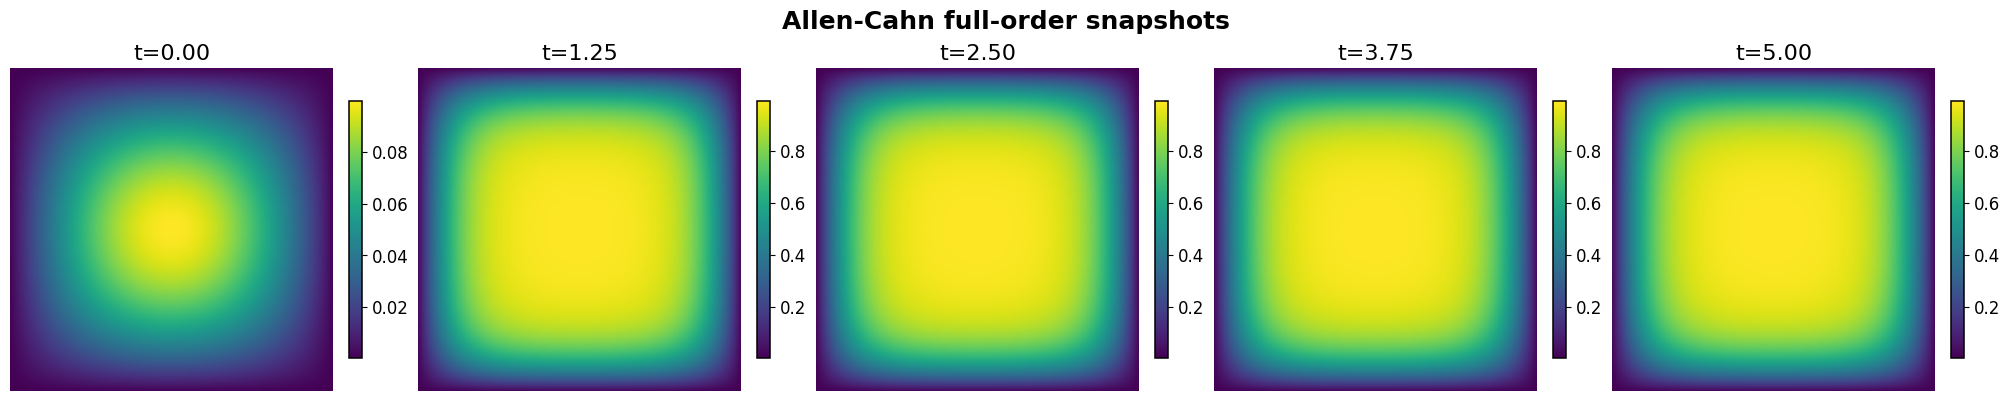

In [45]:
def plot_snapshot_grid(S, n, times, title, n_plots=5):
    indices = np.linspace(0, S.shape[1] - 1, n_plots, dtype=int)

    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), constrained_layout=True)
    for ax, idx in zip(axes, indices):
        im = ax.imshow(S[:, idx].reshape(n, n), origin="lower", cmap="viridis")
        ax.set_title(f"t={times[idx]:.2f}")
        ax.axis("off")
        fig.colorbar(im, ax=ax, shrink=0.75)

    fig.suptitle(title, fontweight="bold")
    plt.show()


plot_snapshot_grid(
    S_ac,
    ac_config.n,
    ac_data["times"],
    "Allen-Cahn full-order snapshots",
    n_plots=5,
)

## 5. POD and rSVD-POD basis comparison for Allen--Cahn

We construct reduced bases from the Allen--Cahn snapshot matrix using:

- classical SVD;
- randomized SVD with different oversampling values \(p\);
- randomized SVD with different power iteration values \(q\).

For each reduced rank \(r\), we compute the projection reconstruction error:

$$
E_r =
\frac{\|S-\Phi_r\Phi_r^T S\|_F}{\|S\|_F}.
$$

The goal is to separate the influence of **oversampling** from the influence of **power iterations**. Larger \(p\) samples a wider random subspace, while larger \(q\) amplifies dominant singular directions before the final SVD. This is especially useful when the singular values decay slowly.


In [46]:
# Reduced ranks to test
r_values = [2, 4, 6, 8, 10, 15, 20]

# More diverse oversampling values.
# p = 0 is the no-oversampling baseline.
# p = 5 is a small oversampling value.
# p = 20 is a standard stronger oversampling value.
# p = 50 is intentionally larger to make the effect visible on large matrices.
oversampling_values = [0, 5, 10, 20]

# Different power-iteration values.
# q = 0 is the fastest but least accurate randomized range finder.
# q = 1 is a common practical default.
# q = 2 often improves accuracy when the singular spectrum decays slowly.
power_iteration_values = [0, 1, 2]

ac_results = []

for r in r_values:
    # Deterministic POD-SVD baseline
    Phi, s, build_time, info = pod_basis(
        S_ac,
        r,
        method="svd",
        svd_mode=SVD_MODE,
        n_repeats=N_EXPERIMENT_REPEATS,
    )
    err = projection_reconstruction_error(S_ac, Phi)
    ac_results.append({
        "method": "POD-SVD",
        "r": info["r_eff"],
        "p": None,
        "p_eff": None,
        "q": None,
        "error": err,
        "time": build_time,
        "time_std": info["time_std"],
    })

    # Randomized POD bases for all combinations of p and q
    for q in power_iteration_values:
        for p in oversampling_values:
            Phi_r, s_r, build_time_r, info = pod_basis(
                S_ac,
                r,
                method="rsvd",
                oversampling=p,
                n_iter=q,
                random_state=42,
                rsvd_inner_svd_mode=RSVD_INNER_SVD_MODE,
                n_repeats=N_EXPERIMENT_REPEATS,
            )
            err_r = projection_reconstruction_error(S_ac, Phi_r)
            ac_results.append({
                "method": "POD-rSVD",
                "r": info["r_eff"],
                "p": p,
                "p_eff": info["p_eff"],
                "q": q,
                "error": err_r,
                "time": build_time_r,
                "time_std": info["time_std"],
            })

# Preview the first rows
for row in ac_results[:12]:
    print(row)

print("Each reported POD basis time is averaged over", N_EXPERIMENT_REPEATS, "runs.")


{'method': 'POD-SVD', 'r': 2, 'p': None, 'p_eff': None, 'q': None, 'error': np.float64(0.0023918696116237257), 'time': 1.0524213889999374, 'time_std': 0.26213691613365303}
{'method': 'POD-rSVD', 'r': 2, 'p': 0, 'p_eff': 0, 'q': 0, 'error': np.float64(0.009789953718987911), 'time': 0.11344051799997032, 'time_std': 0.10850733462809903}
{'method': 'POD-rSVD', 'r': 2, 'p': 5, 'p_eff': 5, 'q': 0, 'error': np.float64(0.0023918696198550696), 'time': 0.13132654719993297, 'time_std': 0.0265437755753956}
{'method': 'POD-rSVD', 'r': 2, 'p': 10, 'p_eff': 10, 'q': 0, 'error': np.float64(0.0023918696116236302), 'time': 0.19208545190003862, 'time_std': 0.048492253875957736}
{'method': 'POD-rSVD', 'r': 2, 'p': 20, 'p_eff': 20, 'q': 0, 'error': np.float64(0.002391869611623731), 'time': 0.32113636509984644, 'time_std': 0.03338999415058913}
{'method': 'POD-rSVD', 'r': 2, 'p': 0, 'p_eff': 0, 'q': 1, 'error': np.float64(0.002391902925437053), 'time': 0.3777296127998852, 'time_std': 0.27086966907778853}
{'m

<>:321: SyntaxWarning: invalid escape sequence '\l'
<>:394: SyntaxWarning: invalid escape sequence '\l'
<>:321: SyntaxWarning: invalid escape sequence '\l'
<>:394: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1675/1757728580.py:321: SyntaxWarning: invalid escape sequence '\l'
  "$\log_{10}$(error)" if quantity in ["error", "mean_error"] else quantity,
/tmp/ipykernel_1675/1757728580.py:394: SyntaxWarning: invalid escape sequence '\l'
  "$\log_{10}$(error)" if quantity == "mean_error" else quantity,


Saved: thesis_figures/allen_cahn_pod_projection_error.pdf
Saved: thesis_figures/allen_cahn_pod_projection_error.png


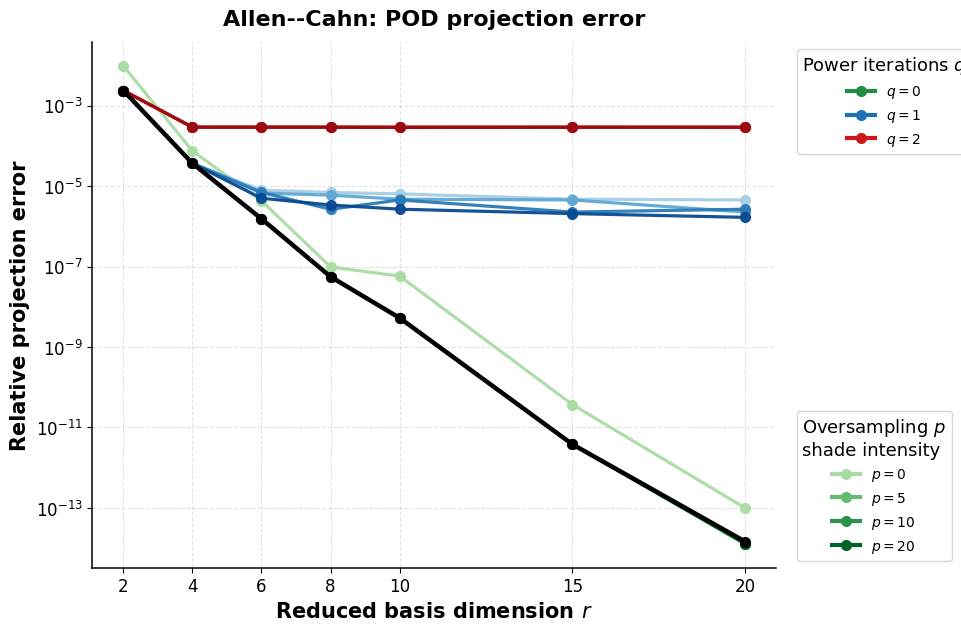

Saved: thesis_figures/allen_cahn_pod_basis_time.pdf
Saved: thesis_figures/allen_cahn_pod_basis_time.png


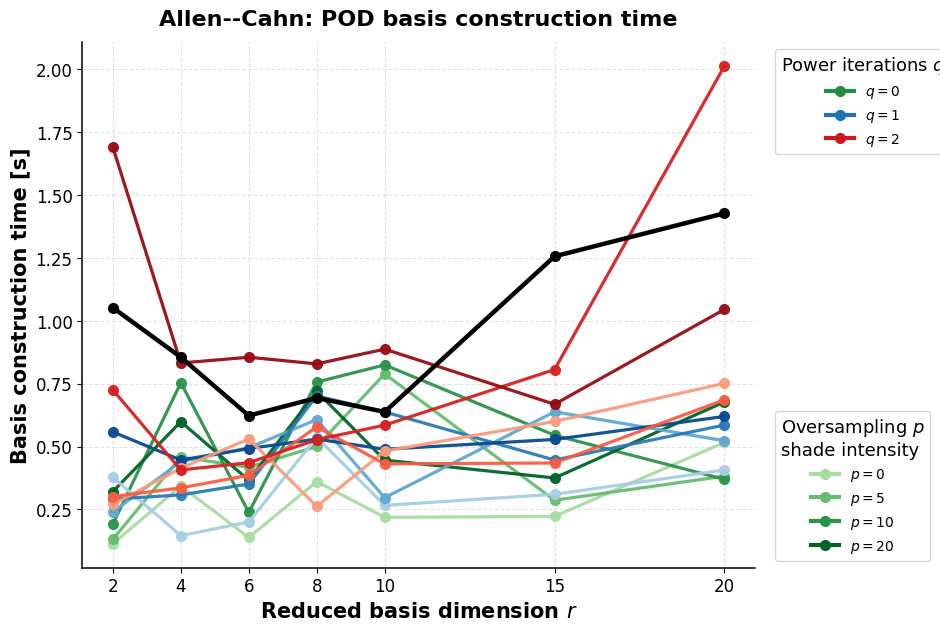

Saved: thesis_figures/allen_cahn_rsvd_error_heatmap.pdf
Saved: thesis_figures/allen_cahn_rsvd_error_heatmap.png


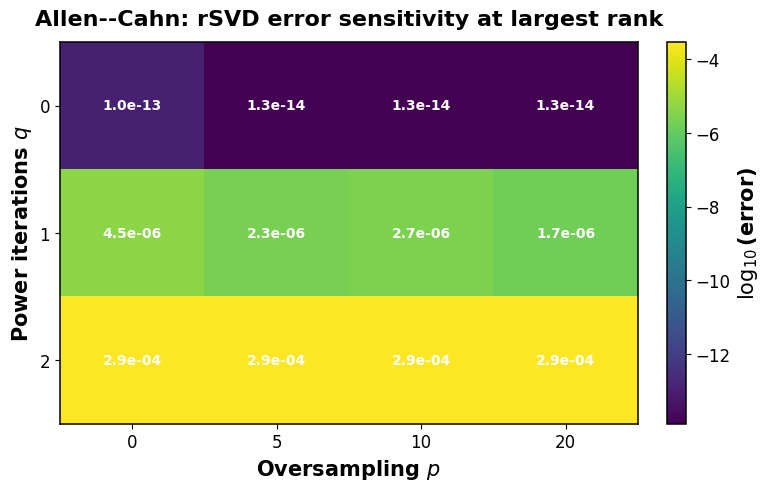

Saved: thesis_figures/allen_cahn_rsvd_time_heatmap.pdf
Saved: thesis_figures/allen_cahn_rsvd_time_heatmap.png


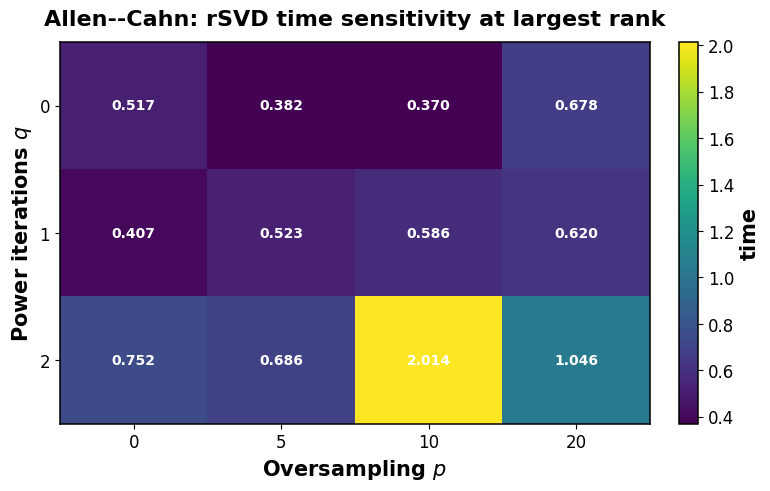

In [61]:
# -----------------------------------------------------------------------------
# Thesis-quality plotting utilities
# -----------------------------------------------------------------------------
# Convention:
#   q = 0 -> green gradient
#   q = 1 -> blue gradient
#   q = 2 -> red gradient
#
# Different p values are represented ONLY by different shades inside the same
# q color family. Marker and linestyle are fixed for every rSVD curve.

Q_COLORMAPS = {
    0: plt.cm.Greens,
    1: plt.cm.Blues,
    2: plt.cm.Reds,
    3: plt.cm.Purples,
}

Q_BASE_COLORS = {
    0: "#238b45",  # green
    1: "#2171b5",  # blue
    2: "#cb181d",  # red
    3: "#6a3d9a",  # fallback purple
}

RSVD_MARKER = "o"
RSVD_LINESTYLE = "-"
RSVD_LINEWIDTH = 2.3

from matplotlib.ticker import FixedLocator

def set_discrete_xticks(ax, values):
    values = sorted(set(int(v) for v in values))
    ax.xaxis.set_major_locator(FixedLocator(values))
    ax.set_xticklabels([str(v) for v in values])


def _safe_name(text):
    """Convert a title into a safe filename."""
    text = text.lower().replace("--", "_").replace(" ", "_")
    text = re.sub(r"[^a-z0-9_]+", "", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text[:120]


def save_thesis_figure(fig, name):
    """Save each figure both as PDF and PNG for LaTeX and quick inspection."""
    pdf_path = os.path.join(FIGURE_DIR, f"{name}.pdf")
    png_path = os.path.join(FIGURE_DIR, f"{name}.png")

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


def _style_for_pq(p, q, all_p_values):
    """
    Return a consistent color/marker/linestyle for a given pair (p,q).

    q selects the color family.
    p selects the shade inside that color family.

    All randomized curves use the same marker and linestyle.
    """
    all_p_values = sorted(all_p_values)
    p_index = all_p_values.index(p)

    if len(all_p_values) == 1:
        shade = 0.75
    else:
        # Use a readable range of the colormap.
        # Lower p -> lighter shade, higher p -> darker shade.
        shade = 0.35 + 0.55 * (p_index / (len(all_p_values) - 1))

    cmap = Q_COLORMAPS.get(q, Q_COLORMAPS[3])
    color = cmap(shade)

    return color, RSVD_MARKER, RSVD_LINESTYLE


def _add_pq_legend(ax, p_values, q_values):
    """
    Add compact legends:
    - q is represented by the color family;
    - p is represented by shade intensity.
    """
    q_handles = [
        mlines.Line2D(
            [],
            [],
            color=Q_BASE_COLORS.get(q, Q_BASE_COLORS[3]),
            marker=RSVD_MARKER,
            linestyle=RSVD_LINESTYLE,
            linewidth=3.0,
            label=rf"$q={q}$",
        )
        for q in sorted(q_values)
    ]

    p_values = sorted(p_values)
    reference_q = sorted(q_values)[0] if q_values else 0

    p_handles = []
    for p in p_values:
        color, marker, linestyle = _style_for_pq(p, reference_q, p_values)
        p_handles.append(
            mlines.Line2D(
                [],
                [],
                color=color,
                marker=marker,
                linestyle=linestyle,
                linewidth=3.0,
                label=rf"$p={p}$",
            )
        )

    leg1 = ax.legend(
        handles=q_handles,
        title="Power iterations $q$",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        frameon=True,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=p_handles,
        title="Oversampling $p$\nshade intensity",
        loc="lower left",
        bbox_to_anchor=(1.02, 0.00),
        frameon=True,
    )


def _finish_axis(ax, xlabel, ylabel, title, logy=False):
    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title, fontweight="bold", pad=12)

    if logy:
        ax.set_yscale("log")

    ax.grid(True, which="both" if logy else "major", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_pod_errors(results, title, filename=None):
    fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)

    svd_rows = sorted(
        [x for x in results if x["method"] == "POD-SVD"],
        key=lambda x: x["r"],
    )

    ax.plot(
        [x["r"] for x in svd_rows],
        [x["error"] for x in svd_rows],
        marker="o",
        label="POD-SVD",
        linewidth=3.2,
        color="black",
        zorder=10,
    )

    rsvd_rows = [x for x in results if x["method"] == "POD-rSVD"]
    p_values = sorted(set(x["p"] for x in rsvd_rows))
    q_values = sorted(set(x["q"] for x in rsvd_rows))

    for q in q_values:
        for p in p_values:
            rows = sorted(
                [x for x in rsvd_rows if x["p"] == p and x["q"] == q],
                key=lambda x: x["r"],
            )
            if not rows:
                continue

            color, marker, linestyle = _style_for_pq(p, q, p_values)

            ax.plot(
                [x["r"] for x in rows],
                [x["error"] for x in rows],
                marker=marker,
                linestyle=linestyle,
                linewidth=RSVD_LINEWIDTH,
                color=color,
                alpha=0.95,
                label=rf"$p={p}, q={q}$",
            )

    _finish_axis(
        ax,
        "Reduced basis dimension $r$",
        "Relative projection error",
        title,
        logy=True,
    )

    x_values = sorted(set(x["r"] for x in svd_rows + rsvd_rows))
    set_discrete_xticks(ax, x_values)

    _add_pq_legend(ax, p_values, q_values)

    if filename is None:
        filename = _safe_name(title)

    save_thesis_figure(fig, filename)
    plt.show()


def plot_pod_times(results, title, filename=None):
    fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)

    svd_rows = sorted(
        [x for x in results if x["method"] == "POD-SVD"],
        key=lambda x: x["r"],
    )

    ax.plot(
        [x["r"] for x in svd_rows],
        [x["time"] for x in svd_rows],
        marker="o",
        label="POD-SVD",
        linewidth=3.2,
        color="black",
        zorder=10,
    )

    rsvd_rows = [x for x in results if x["method"] == "POD-rSVD"]
    p_values = sorted(set(x["p"] for x in rsvd_rows))
    q_values = sorted(set(x["q"] for x in rsvd_rows))

    for q in q_values:
        for p in p_values:
            rows = sorted(
                [x for x in rsvd_rows if x["p"] == p and x["q"] == q],
                key=lambda x: x["r"],
            )
            if not rows:
                continue

            color, marker, linestyle = _style_for_pq(p, q, p_values)

            ax.plot(
                [x["r"] for x in rows],
                [x["time"] for x in rows],
                marker=marker,
                linestyle=linestyle,
                linewidth=RSVD_LINEWIDTH,
                color=color,
                alpha=0.95,
                label=rf"$p={p}, q={q}$",
            )

    _finish_axis(
        ax,
        "Reduced basis dimension $r$",
        "Basis construction time [s]",
        title,
        logy=False,
    )

    x_values = sorted(set(x["r"] for x in svd_rows + rsvd_rows))
    set_discrete_xticks(ax, x_values)

    _add_pq_legend(ax, p_values, q_values)

    if filename is None:
        filename = _safe_name(title)

    save_thesis_figure(fig, filename)
    plt.show()


def plot_rsvd_heatmap_at_rank(results, rank, quantity="error", title=None, filename=None):
    """Heatmap of the influence of p and q at a fixed rank."""
    rows = [
        x for x in results
        if x["method"] == "POD-rSVD" and x["r"] == rank
    ]

    if len(rows) == 0:
        print(f"No rSVD rows found for r={rank}.")
        return

    ps = sorted(set(x["p"] for x in rows))
    qs = sorted(set(x["q"] for x in rows))

    Z = np.full((len(qs), len(ps)), np.nan)

    for i, q in enumerate(qs):
        for j, p in enumerate(ps):
            match = [x for x in rows if x["p"] == p and x["q"] == q]
            if match:
                Z[i, j] = match[0][quantity]

    values_to_show = np.log10(Z) if quantity in ["error", "mean_error"] else Z

    fig, ax = plt.subplots(figsize=(7.6, 4.8), constrained_layout=True)
    im = ax.imshow(values_to_show, aspect="auto", cmap="viridis")

    ax.set_xticks(range(len(ps)))
    ax.set_xticklabels(ps)
    ax.set_yticks(range(len(qs)))
    ax.set_yticklabels(qs)

    ax.set_xlabel("Oversampling $p$", fontweight="bold")
    ax.set_ylabel("Power iterations $q$", fontweight="bold")

    if title is None:
        title = f"rSVD {quantity} at r={rank}"

    ax.set_title(title, fontweight="bold", pad=12)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(
        "$\log_{10}$(error)" if quantity in ["error", "mean_error"] else quantity,
        fontweight="bold",
    )

    for i in range(len(qs)):
        for j in range(len(ps)):
            value = Z[i, j]
            if np.isfinite(value):
                txt = (
                    f"{value:.1e}"
                    if quantity in ["error", "mean_error"]
                    else f"{value:.3f}"
                )
                ax.text(
                    j,
                    i,
                    txt,
                    ha="center",
                    va="center",
                    color="white",
                    fontsize=10,
                    fontweight="bold",
                )

    if filename is None:
        filename = _safe_name(title)

    save_thesis_figure(fig, filename)
    plt.show()


def plot_deim_heatmap_at_m(results, m, quantity="mean_error", title=None, filename=None):
    """Heatmap for POD-rSVD-DEIM quantities at a fixed DEIM dimension m."""
    rows = [
        x for x in results
        if x.get("basis_method") == "rsvd" and x["m"] == m
    ]

    if len(rows) == 0:
        print(f"No rSVD-DEIM rows found for m={m}.")
        return

    ps = sorted(set(x["p"] for x in rows))
    qs = sorted(set(x["q"] for x in rows))

    Z = np.full((len(qs), len(ps)), np.nan)

    for i, q in enumerate(qs):
        for j, p in enumerate(ps):
            match = [x for x in rows if x["p"] == p and x["q"] == q]
            if match:
                Z[i, j] = match[0][quantity]

    values_to_show = np.log10(Z) if quantity in ["mean_error"] else Z

    fig, ax = plt.subplots(figsize=(7.6, 4.8), constrained_layout=True)
    im = ax.imshow(values_to_show, aspect="auto", cmap="viridis")

    ax.set_xticks(range(len(ps)))
    ax.set_xticklabels(ps)
    ax.set_yticks(range(len(qs)))
    ax.set_yticklabels(qs)

    ax.set_xlabel("Oversampling $p$", fontweight="bold")
    ax.set_ylabel("Power iterations $q$", fontweight="bold")

    if title is None:
        title = f"POD-rSVD-DEIM {quantity} at m={m}"

    ax.set_title(title, fontweight="bold", pad=12)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(
        "$\log_{10}$(error)" if quantity == "mean_error" else quantity,
        fontweight="bold",
    )

    for i in range(len(qs)):
        for j in range(len(ps)):
            value = Z[i, j]
            if np.isfinite(value):
                txt = f"{value:.1e}" if quantity == "mean_error" else f"{value:.3f}"
                ax.text(
                    j,
                    i,
                    txt,
                    ha="center",
                    va="center",
                    color="white",
                    fontsize=10,
                    fontweight="bold",
                )

    if filename is None:
        filename = _safe_name(title)

    save_thesis_figure(fig, filename)
    plt.show()


def plot_deim_comparison(results, title_prefix, filename_prefix=None):
    """
    Thesis-quality comparison for POD-DEIM and POD-rSVD-DEIM.
    Produces line plots for error, basis time, and evaluation time.
    """
    if filename_prefix is None:
        filename_prefix = _safe_name(title_prefix)

    svd_rows = sorted(
        [x for x in results if x.get("basis_method") == "svd"],
        key=lambda x: x["m"],
    )

    rsvd_rows = [x for x in results if x.get("basis_method") == "rsvd"]

    p_values = sorted(set(x["p"] for x in rsvd_rows)) if rsvd_rows else []
    q_values = sorted(set(x["q"] for x in rsvd_rows)) if rsvd_rows else []

    # -------------------------------------------------------------------------
    # 1) Nonlinear approximation error
    # -------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)

    if svd_rows:
      ax.plot(
          [x["m"] for x in svd_rows],
          [x["mean_error"] for x in svd_rows],
          marker="o",
          linewidth=3.2,
          color="black",
          label="POD-DEIM",
          zorder=10,
      )

    for q in q_values:
        for p in p_values:
            rows = sorted(
                [x for x in rsvd_rows if x["p"] == p and x["q"] == q],
                key=lambda x: x["m"],
            )

            if not rows:
                continue

            color, marker, linestyle = _style_for_pq(p, q, p_values)

            ax.plot(
                [x["m"] for x in rows],
                [x["mean_error"] for x in rows],
                marker=marker,
                linestyle=linestyle,
                linewidth=RSVD_LINEWIDTH,
                color=color,
                alpha=0.95,
                label=rf"$p={p}, q={q}$",
            )

    _finish_axis(
        ax,
        "DEIM basis dimension $m$",
        "Relative nonlinear approximation error",
        f"{title_prefix}: DEIM approximation error",
        logy=True,
    )

    x_values = sorted(set(x["m"] for x in svd_rows + rsvd_rows))
    set_discrete_xticks(ax, x_values)

    if p_values and q_values:
        _add_pq_legend(ax, p_values, q_values)

    save_thesis_figure(fig, f"{filename_prefix}_deim_error")
    plt.show()

    # -------------------------------------------------------------------------
    # 2) Nonlinear basis construction time
    # -------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)

    if svd_rows:
        ax.plot(
            [x["m"] for x in svd_rows],
            [x["basis_time"] for x in svd_rows],
            marker="o",
            linewidth=3.2,
            color="black",
            label="POD-DEIM",
            zorder=10,
        )

    for q in q_values:
        for p in p_values:
            rows = sorted(
                [x for x in rsvd_rows if x["p"] == p and x["q"] == q],
                key=lambda x: x["m"],
            )

            if not rows:
                continue

            color, marker, linestyle = _style_for_pq(p, q, p_values)

            ax.plot(
                [x["m"] for x in rows],
                [x["basis_time"] for x in rows],
                marker=marker,
                linestyle=linestyle,
                linewidth=RSVD_LINEWIDTH,
                color=color,
                alpha=0.95,
            )

    _finish_axis(
        ax,
        "DEIM basis dimension $m$",
        "Nonlinear basis construction time [s]",
        f"{title_prefix}: nonlinear basis construction time",
        logy=False,
    )

    x_values = sorted(set(x["m"] for x in svd_rows + rsvd_rows))
    set_discrete_xticks(ax, x_values)

    if p_values and q_values:
        _add_pq_legend(ax, p_values, q_values)

    save_thesis_figure(fig, f"{filename_prefix}_deim_basis_time")
    plt.show()

    # -------------------------------------------------------------------------
    # 3) Nonlinear evaluation time
    # -------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)

    if svd_rows:
        ax.plot(
            [x["m"] for x in svd_rows],
            [x["full_time"] for x in svd_rows],
            marker="o",
            linewidth=3.0,
            color="0.25",
            linestyle=":",
            label="Full nonlinear evaluation",
        )

        ax.plot(
            [x["m"] for x in svd_rows],
            [x["deim_time"] for x in svd_rows],
            marker="o",
            linewidth=3.2,
            color="black",
            label="POD-DEIM evaluation",
            zorder=10,
        )

    for q in q_values:
        for p in p_values:
            rows = sorted(
                [x for x in rsvd_rows if x["p"] == p and x["q"] == q],
                key=lambda x: x["m"],
            )

            if not rows:
                continue

            color, marker, linestyle = _style_for_pq(p, q, p_values)

            ax.plot(
                [x["m"] for x in rows],
                [x["deim_time"] for x in rows],
                marker=marker,
                linestyle=linestyle,
                linewidth=RSVD_LINEWIDTH,
                color=color,
                alpha=0.95,
            )

    _finish_axis(
        ax,
        "DEIM basis dimension $m$",
        "Average evaluation time [s]",
        f"{title_prefix}: nonlinear evaluation time",
        logy=False,
    )

    x_values = sorted(set(x["m"] for x in svd_rows + rsvd_rows))
    set_discrete_xticks(ax, x_values)

    if p_values and q_values:
        _add_pq_legend(ax, p_values, q_values)

    save_thesis_figure(fig, f"{filename_prefix}_deim_eval_time")
    plt.show()

    # -------------------------------------------------------------------------
    # 4) Heatmaps at largest m
    # -------------------------------------------------------------------------
    if rsvd_rows:
        max_m = max(x["m"] for x in rsvd_rows)

        plot_deim_heatmap_at_m(
            results,
            m=max_m,
            quantity="mean_error",
            title=f"{title_prefix}: rSVD-DEIM error sensitivity at largest m",
            filename=f"{filename_prefix}_rsvd_deim_error_heatmap",
        )

        plot_deim_heatmap_at_m(
            results,
            m=max_m,
            quantity="basis_time",
            title=f"{title_prefix}: rSVD-DEIM basis-time sensitivity at largest m",
            filename=f"{filename_prefix}_rsvd_deim_basis_time_heatmap",
        )


plot_pod_errors(
    ac_results,
    "Allen--Cahn: POD projection error",
    filename="allen_cahn_pod_projection_error",
)

plot_pod_times(
    ac_results,
    "Allen--Cahn: POD basis construction time",
    filename="allen_cahn_pod_basis_time",
)

plot_rsvd_heatmap_at_rank(
    ac_results,
    rank=max(r_values),
    quantity="error",
    title="Allen--Cahn: rSVD error sensitivity at largest rank",
    filename="allen_cahn_rsvd_error_heatmap",
)

plot_rsvd_heatmap_at_rank(
    ac_results,
    rank=max(r_values),
    quantity="time",
    title="Allen--Cahn: rSVD time sensitivity at largest rank",
    filename="allen_cahn_rsvd_time_heatmap",
)

## 6. Allen-Cahn POD-DEIM and POD-rSVD-DEIM nonlinear approximation

The nonlinear term is

$$
f(y)=\mu(y-y^3).
$$

The DEIM approximation is

$$
f(y)\approx U_f(P^T U_f)^{-1}P^T f(y).
$$

Here we compare two ways of constructing the nonlinear DEIM basis $U_f$:

1. **POD-DEIM**: $U_f$ is computed from nonlinear snapshots using classical SVD;
2. **POD-rSVD-DEIM**: $U_f$ is computed from nonlinear snapshots using randomized SVD.

This makes the experiment more complete: rSVD accelerates basis construction, while DEIM accelerates nonlinear evaluation.


In [48]:
def allen_cahn_nonlinearity(y, mu):
    return mu * (y - y**3)


m_deim_values = [2, 4, 6, 8, 10, 15, 20]

# Use the same rSVD grid for the DEIM nonlinear basis.
# This tests whether the DEIM basis itself can be built accurately with rSVD.
rsvd_deim_oversampling_values = [0, 5, 10, 20]
rsvd_deim_power_iteration_values = [0, 1, 2]

split = int(0.7 * S_ac.shape[1])
S_train = S_ac[:, :split]
F_train = F_ac[:, :split]
S_test = S_ac[:, split:]
F_test = F_ac[:, split:]

# Classical POD-DEIM: nonlinear basis from deterministic SVD
ac_deim_svd_results = deim_analysis(
    F_train=F_train,
    S_test=S_test,
    nonlinear_function=lambda y: allen_cahn_nonlinearity(y, ac_config.mu),
    m_values=m_deim_values,
    basis_method="svd",
    n_repeats=5,
    n_basis_repeats=N_EXPERIMENT_REPEATS,
    svd_mode=SVD_MODE,
)

# POD-rSVD-DEIM: nonlinear basis from randomized SVD, for several p and q values
ac_deim_rsvd_results = []
for q in rsvd_deim_power_iteration_values:
    for p in rsvd_deim_oversampling_values:
        ac_deim_rsvd_results.extend(
            deim_analysis(
                F_train=F_train,
                S_test=S_test,
                nonlinear_function=lambda y: allen_cahn_nonlinearity(y, ac_config.mu),
                m_values=m_deim_values,
                basis_method="rsvd",
                oversampling=p,
                n_iter=q,
                random_state=42,
                n_repeats=5,
                n_basis_repeats=N_EXPERIMENT_REPEATS,
                rsvd_inner_svd_mode=RSVD_INNER_SVD_MODE,
            )
        )

ac_deim_results = ac_deim_svd_results + ac_deim_rsvd_results

for row in ac_deim_results[:12]:
    print(row)


{'method': 'POD-DEIM', 'basis_method': 'svd', 'm': 2, 'p': None, 'p_eff': None, 'q': None, 'basis_time': 3.707177930099897, 'basis_time_std': 1.03742568355309, 'mean_error': 0.009580463273229405, 'std_error': 3.469446951953614e-18, 'full_time': 0.010434530091834695, 'deim_time': 0.0003413982852523122, 'speedup': 30.564096372431987, 'n_deim_points': 2}
{'method': 'POD-DEIM', 'basis_method': 'svd', 'm': 4, 'p': None, 'p_eff': None, 'q': None, 'basis_time': 3.8980641604000086, 'basis_time_std': 0.7715452326548735, 'mean_error': 0.00019410810885228517, 'std_error': 5.421010862427522e-20, 'full_time': 0.011040480891785933, 'deim_time': 0.0004809309049453643, 'speedup': 22.956480397200043, 'n_deim_points': 4}
{'method': 'POD-DEIM', 'basis_method': 'svd', 'm': 6, 'p': None, 'p_eff': None, 'q': None, 'basis_time': 3.7411885929001074, 'basis_time_std': 0.7978816649256707, 'mean_error': 7.237662760137847e-06, 'std_error': 1.6940658945086007e-21, 'full_time': 0.010754763980361024, 'deim_time': 0.

Saved: thesis_figures/allen_cahn_deim_error.pdf
Saved: thesis_figures/allen_cahn_deim_error.png


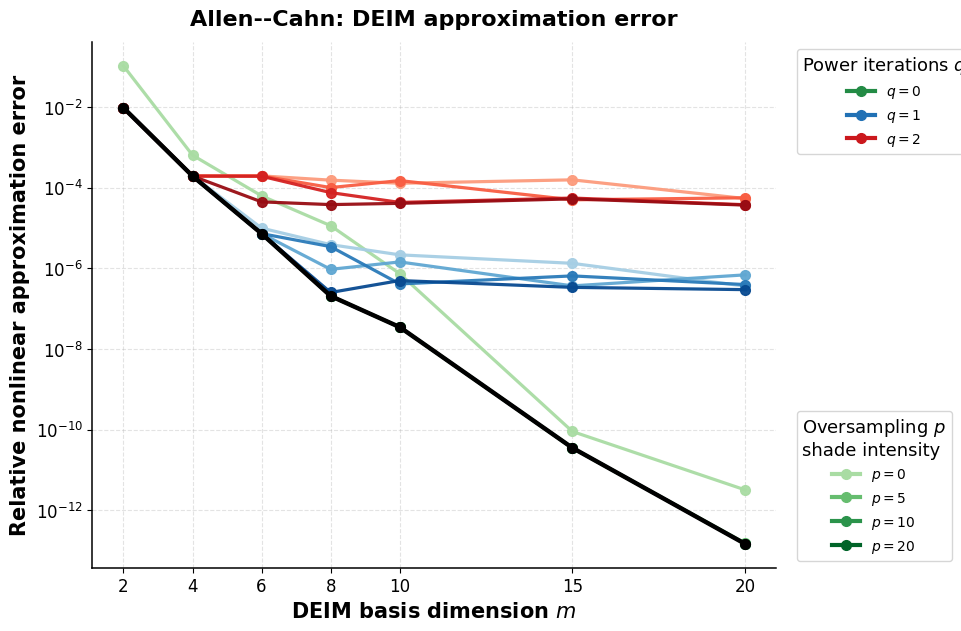

Saved: thesis_figures/allen_cahn_deim_basis_time.pdf
Saved: thesis_figures/allen_cahn_deim_basis_time.png


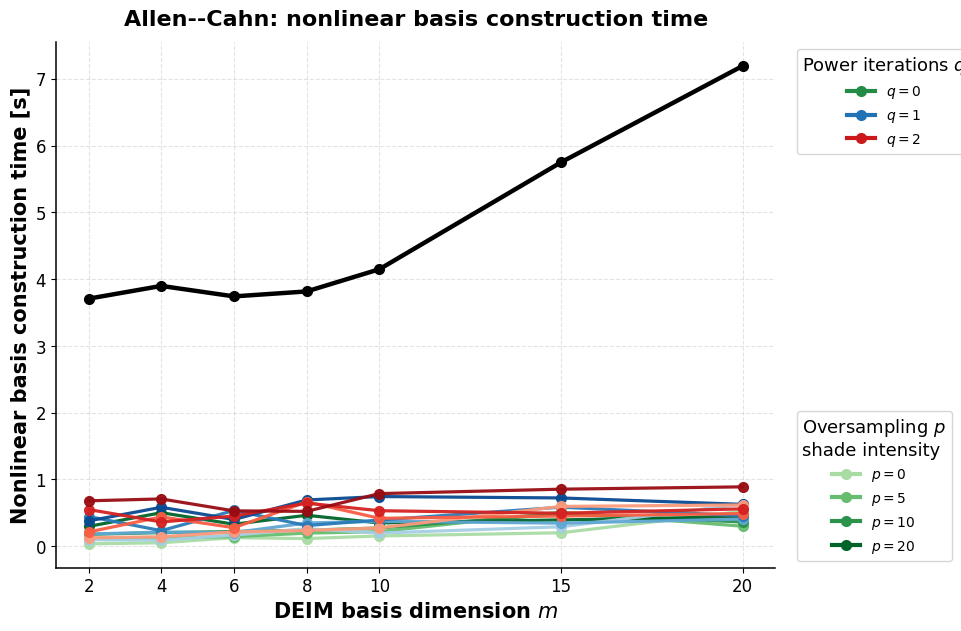

Saved: thesis_figures/allen_cahn_deim_eval_time.pdf
Saved: thesis_figures/allen_cahn_deim_eval_time.png


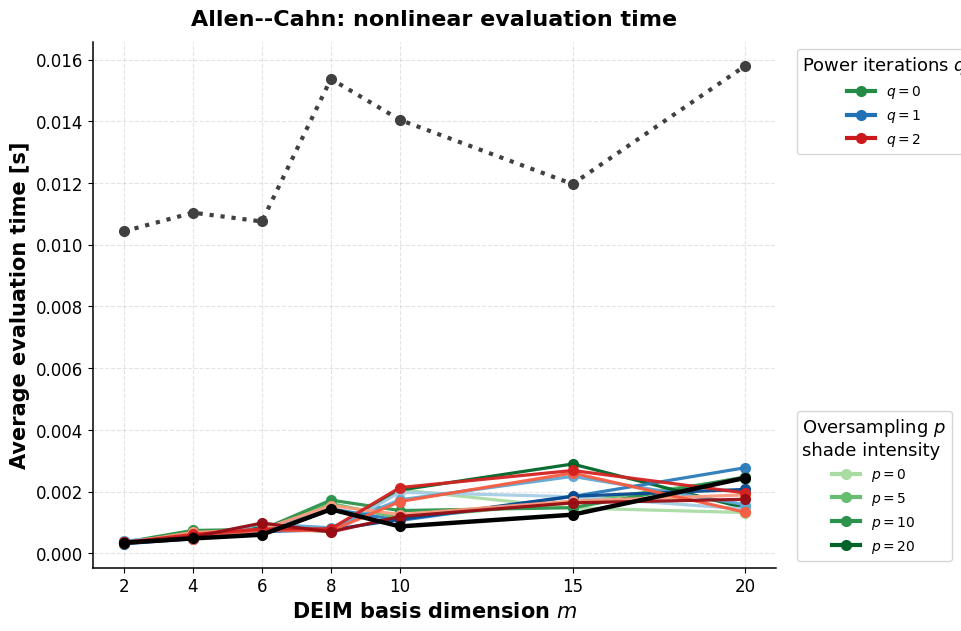

Saved: thesis_figures/allen_cahn_rsvd_deim_error_heatmap.pdf
Saved: thesis_figures/allen_cahn_rsvd_deim_error_heatmap.png


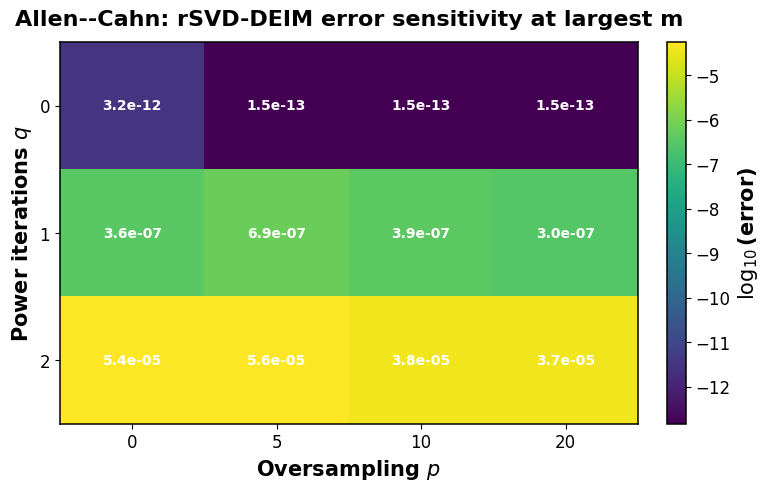

Saved: thesis_figures/allen_cahn_rsvd_deim_basis_time_heatmap.pdf
Saved: thesis_figures/allen_cahn_rsvd_deim_basis_time_heatmap.png


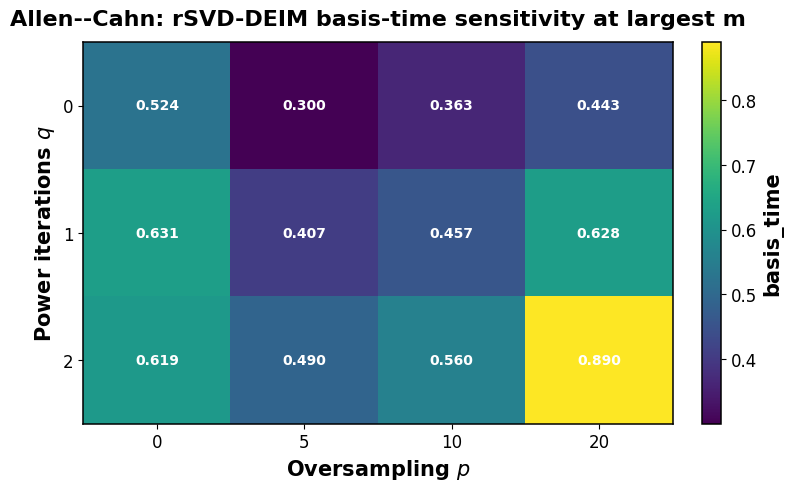

In [62]:
plot_deim_comparison(
    ac_deim_results,
    title_prefix="Allen--Cahn",
    filename_prefix="allen_cahn",
)


# Part B: Nonlinear steady-state elliptic problem

We now study the benchmark nonlinear elliptic problem:

$$
-\nabla^2 u(x,y)+s(u(x,y);\mu)=100\sin(2\pi x)\sin(2\pi y),
$$

where

$$
s(u;\mu)=\frac{\mu_1}{\mu_2}\left(e^{\mu_2u}-1\right),
\qquad
\mu=(\mu_1,\mu_2)\in[0.01,10]^2.
$$

After finite-difference discretization, we solve the nonlinear algebraic system using Newton's method.

## 7. Full-order solver for the nonlinear elliptic problem

In [50]:
@dataclass
class EllipticConfig:
    n: int = 256
    newton_tol: float = 1e-10
    newton_max_iter: int = 30


def elliptic_rhs(X, Y):
    return 100.0 * np.sin(2 * np.pi * X) * np.sin(2 * np.pi * Y)


def nonlinear_s(u, mu1, mu2):
    """
    s(u; mu) = (mu1/mu2)(exp(mu2 u)-1)
    """
    z = np.clip(mu2 * u, -50, 50)
    return (mu1 / mu2) * (np.exp(z) - 1.0)


def nonlinear_s_prime(u, mu1, mu2):
    """
    derivative of s(u; mu) wrt u: mu1 exp(mu2 u)
    """
    z = np.clip(mu2 * u, -50, 50)
    return mu1 * np.exp(z)


def solve_elliptic(mu1, mu2, config, initial_guess=None, verbose=False):
    """
    Solve:
        -Delta u + s(u; mu) = rhs
    with homogeneous Dirichlet BCs.

    Since L approximates Delta, the discrete residual is:
        F(u) = -L u + s(u) - rhs.
    """
    L, h, X, Y = make_laplacian_2d(config.n)
    N = config.n**2
    rhs = elliptic_rhs(X, Y).reshape(-1)

    if initial_guess is None:
        u = np.zeros(N)
    else:
        u = initial_guess.copy()

    t0 = time.perf_counter()
    converged = False

    for it in range(config.newton_max_iter):
        F = -L @ u + nonlinear_s(u, mu1, mu2) - rhs
        res = la.norm(F) / max(la.norm(rhs), 1e-14)

        if verbose:
            print(f"Newton iter {it:02d}, residual={res:.3e}")

        if res < config.newton_tol:
            converged = True
            break

        J = -L + sp.diags(nonlinear_s_prime(u, mu1, mu2), 0, format="csr")
        du = spla.spsolve(J.tocsc(), -F)
        u = u + du

    elapsed = time.perf_counter() - t0

    return {
        "u": u,
        "elapsed": elapsed,
        "converged": converged,
        "iterations": it + 1,
        "grid": (X, Y),
    }


ell_config = EllipticConfig()

test_sol = solve_elliptic(mu1=1.0, mu2=1.0, config=ell_config, verbose=False)
print("Converged:", test_sol["converged"])
print("Newton iterations:", test_sol["iterations"])
print(f"Solve time: {test_sol['elapsed']:.3f} s")

Converged: True
Newton iterations: 4
Solve time: 1.883 s


## 8. Generate parameterized snapshots

We sample a small training grid in the parameter domain:

$$
(\mu_1,\mu_2)\in[0.01,10]^2.
$$

For each parameter pair, the nonlinear PDE is solved using Newton's method.
The resulting solution vectors form the snapshot matrix.

In [51]:
mu1_values = np.linspace(0.01, 10.0, 16)
mu2_values = np.linspace(0.01, 10.0, 16)

ell_snapshots = []
ell_nonlinear_snapshots = []
ell_params = []
ell_solve_times = []

previous_u = None

for mu1 in mu1_values:
    for mu2 in mu2_values:
        sol = solve_elliptic(mu1, mu2, ell_config, initial_guess=previous_u)
        if not sol["converged"]:
            print(f"Warning: Newton did not fully converge for mu=({mu1:.2f},{mu2:.2f})")

        u = sol["u"]
        previous_u = u

        ell_snapshots.append(u)
        ell_nonlinear_snapshots.append(nonlinear_s(u, mu1, mu2))
        ell_params.append((mu1, mu2))
        ell_solve_times.append(sol["elapsed"])

S_ell = np.column_stack(ell_snapshots)
F_ell = np.column_stack(ell_nonlinear_snapshots)

print("Elliptic snapshot matrix shape:", S_ell.shape)
print("Elliptic nonlinear snapshot matrix shape:", F_ell.shape)
print(f"Mean full-order solve time: {np.mean(ell_solve_times):.3f} s")

Elliptic snapshot matrix shape: (65536, 256)
Elliptic nonlinear snapshot matrix shape: (65536, 256)
Mean full-order solve time: 2.192 s


## 9. Visualize selected elliptic solutions

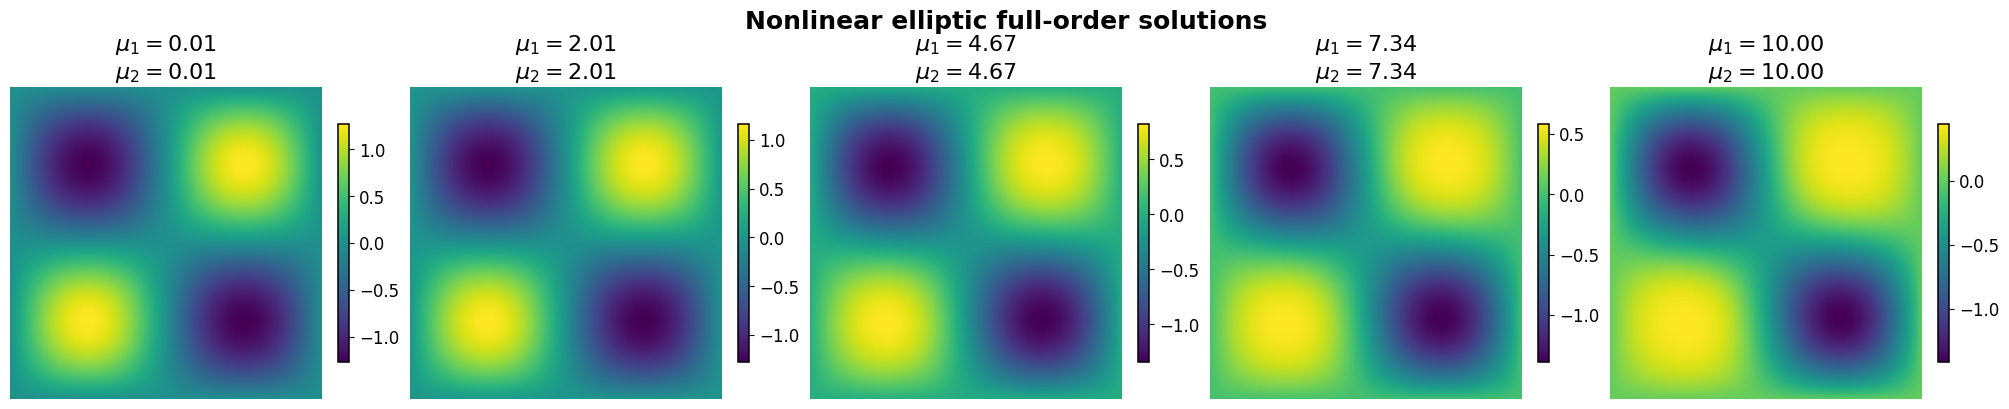

In [59]:
def plot_elliptic_solutions_diagonal(S, params, n, grid_size=16, n_plots=5):
    diag_ids = np.linspace(0, grid_size - 1, n_plots, dtype=int)

    indices = []
    for i in diag_ids:
        idx = i * grid_size + i
        indices.append(idx)

    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), constrained_layout=True)

    for ax, idx in zip(axes, indices):
        im = ax.imshow(S[:, idx].reshape(n, n), origin="lower", cmap="viridis")
        mu1, mu2 = params[idx]
        ax.set_title(rf"$\mu_1={mu1:.2f}$" + "\n" + rf"$\mu_2={mu2:.2f}$")
        ax.axis("off")
        fig.colorbar(im, ax=ax, shrink=0.75)

    fig.suptitle("Nonlinear elliptic full-order solutions", fontweight="bold")
    plt.show()


plot_elliptic_solutions_diagonal(S_ell, ell_params, ell_config.n, grid_size=16, n_plots=5)

## 10. POD and rSVD-POD comparison for the elliptic problem

We repeat the same reduced-basis analysis:

$$
E_r =
\frac{\|S-\Phi_r\Phi_r^T S\|_F}{\|S\|_F}.
$$

This measures how accurately the reduced basis reconstructs the parameterized solution manifold.

Saved: thesis_figures/elliptic_pod_projection_error.pdf
Saved: thesis_figures/elliptic_pod_projection_error.png


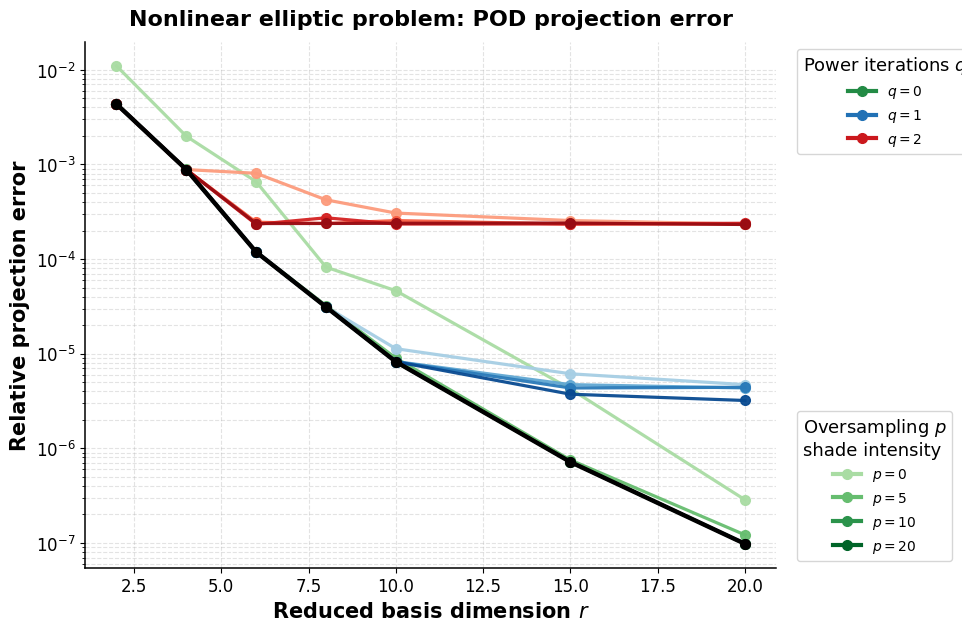

Saved: thesis_figures/elliptic_pod_basis_time.pdf
Saved: thesis_figures/elliptic_pod_basis_time.png


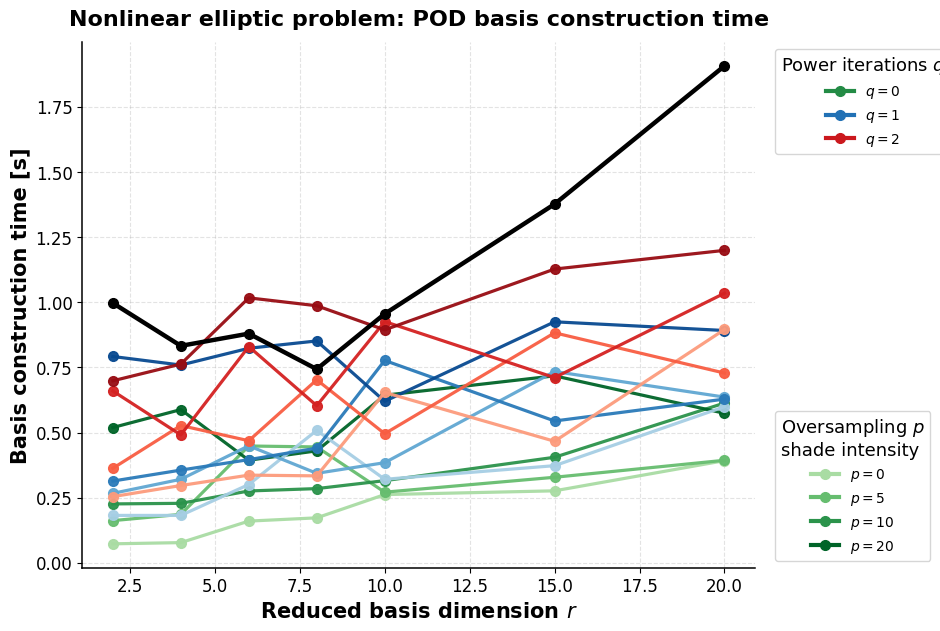

Saved: thesis_figures/elliptic_rsvd_error_heatmap.pdf
Saved: thesis_figures/elliptic_rsvd_error_heatmap.png


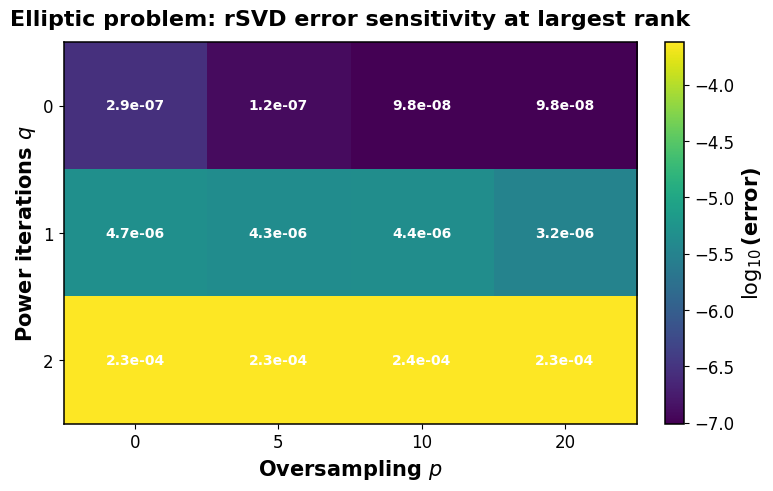

Saved: thesis_figures/elliptic_rsvd_time_heatmap.pdf
Saved: thesis_figures/elliptic_rsvd_time_heatmap.png


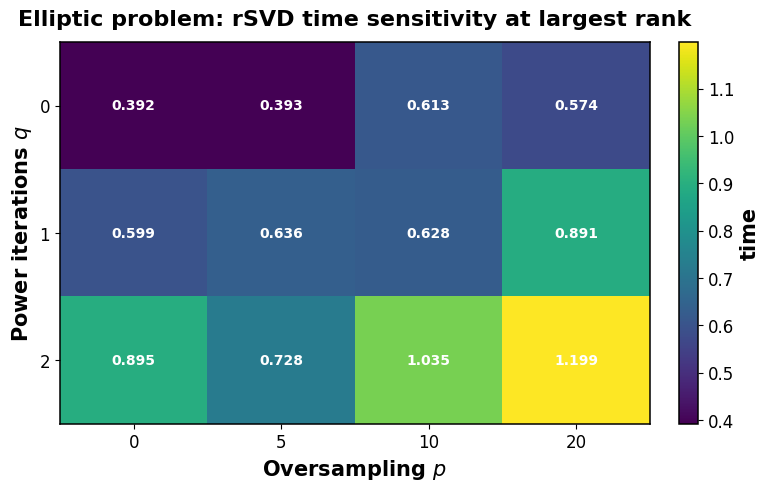

Each reported POD basis time is averaged over 10 runs.


In [53]:
r_values_ell = [2, 4, 6, 8, 10, 15, 20]
oversampling_values_ell = [0, 5, 10, 20]
power_iteration_values_ell = [0, 1, 2]

ell_results = []

for r in r_values_ell:
    r_eff = min(r, min(S_ell.shape) - 1)

    # Deterministic POD-SVD baseline
    Phi, s, build_time, info = pod_basis(
        S_ell,
        r_eff,
        method="svd",
        svd_mode=SVD_MODE,
        n_repeats=N_EXPERIMENT_REPEATS,
    )
    err = projection_reconstruction_error(S_ell, Phi)
    ell_results.append({
        "method": "POD-SVD",
        "r": info["r_eff"],
        "p": None,
        "p_eff": None,
        "q": None,
        "error": err,
        "time": build_time,
        "time_std": info["time_std"],
    })

    # Randomized POD bases for all combinations of p and q
    for q in power_iteration_values_ell:
        for p in oversampling_values_ell:
            Phi_r, s_r, build_time_r, info = pod_basis(
                S_ell,
                r_eff,
                method="rsvd",
                oversampling=p,
                n_iter=q,
                random_state=42,
                rsvd_inner_svd_mode=RSVD_INNER_SVD_MODE,
                n_repeats=N_EXPERIMENT_REPEATS,
            )
            err_r = projection_reconstruction_error(S_ell, Phi_r)
            ell_results.append({
                "method": "POD-rSVD",
                "r": info["r_eff"],
                "p": p,
                "p_eff": info["p_eff"],
                "q": q,
                "error": err_r,
                "time": build_time_r,
                "time_std": info["time_std"],
            })



Saved: thesis_figures/elliptic_pod_projection_error.pdf
Saved: thesis_figures/elliptic_pod_projection_error.png


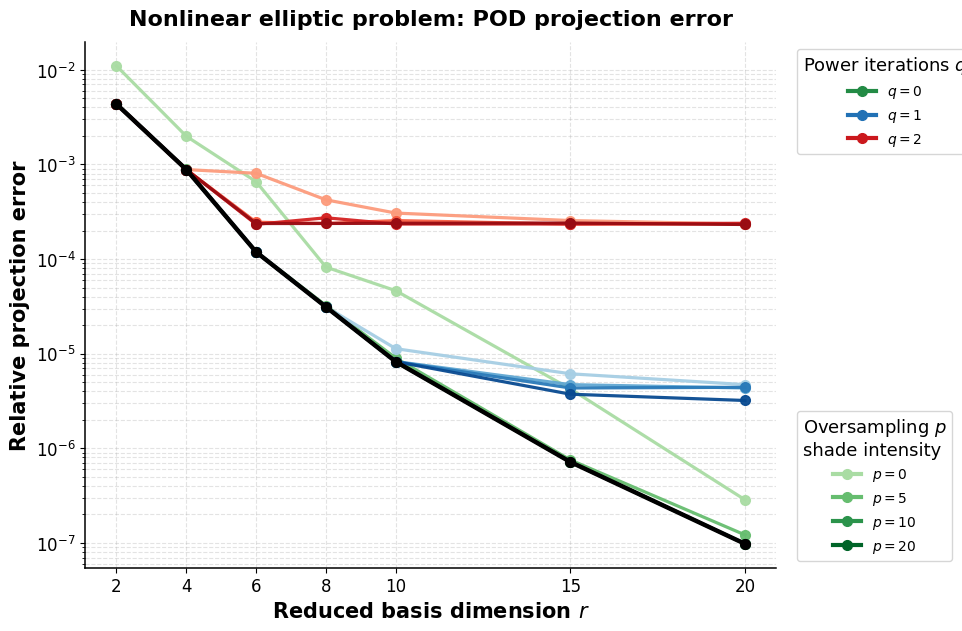

Saved: thesis_figures/elliptic_pod_basis_time.pdf
Saved: thesis_figures/elliptic_pod_basis_time.png


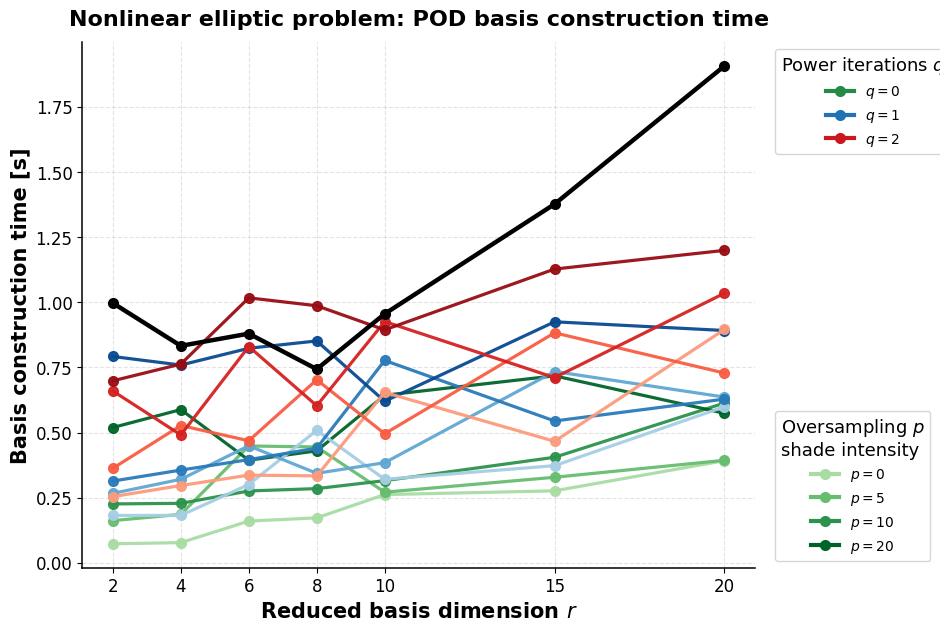

Saved: thesis_figures/elliptic_rsvd_error_heatmap.pdf
Saved: thesis_figures/elliptic_rsvd_error_heatmap.png


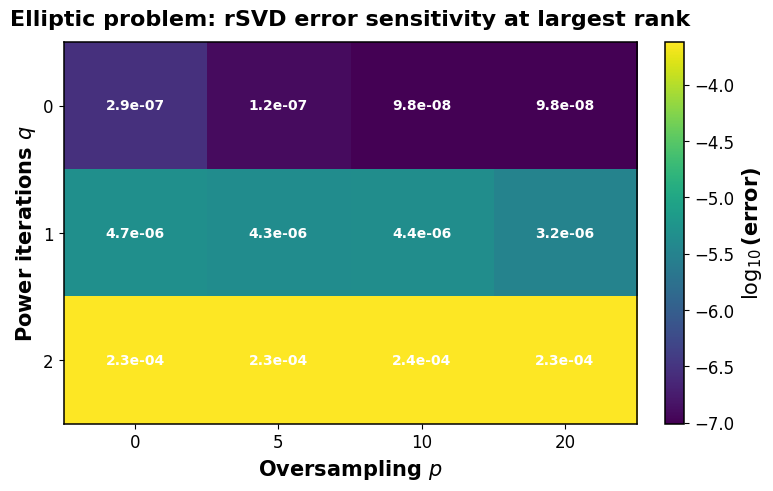

Saved: thesis_figures/elliptic_rsvd_time_heatmap.pdf
Saved: thesis_figures/elliptic_rsvd_time_heatmap.png


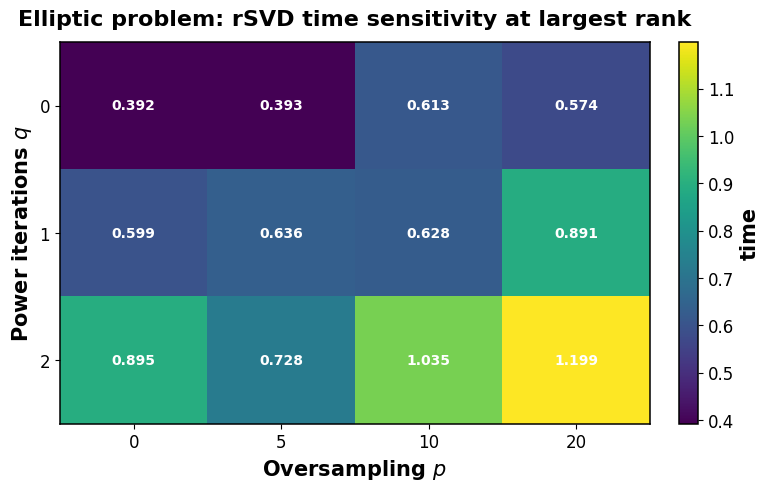

Each reported POD basis time is averaged over 10 runs.


In [63]:
plot_pod_errors(ell_results, "Nonlinear elliptic problem: POD projection error", filename="elliptic_pod_projection_error")
plot_pod_times(ell_results, "Nonlinear elliptic problem: POD basis construction time", filename="elliptic_pod_basis_time")
plot_rsvd_heatmap_at_rank(ell_results, rank=max(r_values_ell), quantity="error", title="Elliptic problem: rSVD error sensitivity at largest rank", filename="elliptic_rsvd_error_heatmap")
plot_rsvd_heatmap_at_rank(ell_results, rank=max(r_values_ell), quantity="time", title="Elliptic problem: rSVD time sensitivity at largest rank", filename="elliptic_rsvd_time_heatmap")

print("Each reported POD basis time is averaged over", N_EXPERIMENT_REPEATS, "runs.")

## 11. POD-DEIM and POD-rSVD-DEIM analysis for the elliptic nonlinear term

The nonlinear term is

$$
s(u;\mu)=\frac{\mu_1}{\mu_2}\left(e^{\mu_2u}-1\right).
$$

For each test snapshot, we compare the exact nonlinear vector with its DEIM approximation.
As for Allen-Cahn, we compute the nonlinear DEIM basis using either classical SVD or randomized SVD.


In [54]:
m_deim_values_ell = [2, 4, 6, 8, 10, 15, 20]
rsvd_deim_oversampling_values_ell = [0, 5, 10, 20]
rsvd_deim_power_iteration_values_ell = [0, 1, 2]

split = int(0.7 * S_ell.shape[1])
S_train_ell = S_ell[:, :split]
F_train_ell = F_ell[:, :split]
S_test_ell = S_ell[:, split:]
F_test_ell = F_ell[:, split:]
params_test_ell = ell_params[split:]

# For the elliptic problem, the nonlinear function depends on the parameter mu.
# We therefore build a list of nonlinear functions, one for each test sample.
def make_elliptic_nonlinear_function(mu1, mu2):
    return lambda u: nonlinear_s(u, mu1, mu2)


def elliptic_deim_analysis(
    F_train,
    S_test,
    params_test,
    m_values,
    basis_method="svd",
    oversampling=10,
    n_iter=1,
    n_repeats=10,
    n_basis_repeats=None,
    svd_mode=None,
    rsvd_inner_svd_mode=None,
):
    results = []
    if n_basis_repeats is None:
        n_basis_repeats = N_EXPERIMENT_REPEATS

    for m in m_values:
        U_f, sf, build_time, info = pod_basis(
            F_train,
            m,
            method=basis_method,
            oversampling=oversampling,
            n_iter=n_iter,
            random_state=42,
            svd_mode=svd_mode,
            rsvd_inner_svd_mode=rsvd_inner_svd_mode,
            n_repeats=n_basis_repeats,
        )
        m_eff = info["r_eff"]
        indices = deim(U_f)

        errors = []
        full_times = []
        deim_times = []

        for j in range(S_test.shape[1]):
            u = S_test[:, j]
            mu1, mu2 = params_test[j]
            nonlinear_function = make_elliptic_nonlinear_function(mu1, mu2)
            f_true = nonlinear_function(u)

            _, full_t, _ = time_function(lambda: nonlinear_function(u), n_repeats=n_repeats)
            f_deim, deim_t, _ = time_function(lambda: deim_approximation(f_true, U_f, indices), n_repeats=n_repeats)

            denom = la.norm(f_true)
            errors.append(la.norm(f_true - f_deim) / denom if denom > 0 else 0.0)
            full_times.append(full_t)
            deim_times.append(deim_t)

        label = "POD-DEIM" if basis_method == "svd" else f"p={oversampling}, q={n_iter}"
        results.append({
            "method": label,
            "basis_method": basis_method,
            "m": m_eff,
            "p": None if basis_method == "svd" else oversampling,
            "p_eff": info["p_eff"],
            "q": None if basis_method == "svd" else n_iter,
            "basis_time": float(build_time),
            "basis_time_std": info["time_std"],
            "mean_error": float(np.mean(errors)),
            "std_error": float(np.std(errors)),
            "full_time": float(np.mean(full_times)),
            "deim_time": float(np.mean(deim_times)),
            "speedup": float(np.mean(full_times) / np.mean(deim_times)) if np.mean(deim_times) > 0 else np.inf,
            "n_deim_points": int(len(indices)),
        })

    return results


ell_deim_svd_results = elliptic_deim_analysis(
    F_train=F_train_ell,
    S_test=S_test_ell,
    params_test=params_test_ell,
    m_values=m_deim_values_ell,
    basis_method="svd",
    n_repeats=10,
    n_basis_repeats=N_EXPERIMENT_REPEATS,
    svd_mode=SVD_MODE,
)

ell_deim_rsvd_results = []
for q in rsvd_deim_power_iteration_values_ell:
    for p in rsvd_deim_oversampling_values_ell:
        ell_deim_rsvd_results.extend(
            elliptic_deim_analysis(
                F_train=F_train_ell,
                S_test=S_test_ell,
                params_test=params_test_ell,
                m_values=m_deim_values_ell,
                basis_method="rsvd",
                oversampling=p,
                n_iter=q,
                n_repeats=10,
                n_basis_repeats=N_EXPERIMENT_REPEATS,
                rsvd_inner_svd_mode=RSVD_INNER_SVD_MODE,
            )
        )

ell_deim_results = ell_deim_svd_results + ell_deim_rsvd_results

for row in ell_deim_results[:12]:
    print(row)


{'method': 'POD-DEIM', 'basis_method': 'svd', 'm': 2, 'p': None, 'p_eff': None, 'q': None, 'basis_time': 8.827524212199933, 'basis_time_std': 0.49078135335127265, 'mean_error': 0.0969018032449536, 'std_error': 0.09107692879127917, 'full_time': 0.0019470796129783818, 'deim_time': 0.00025535746109352507, 'speedup': 7.6249176532392795, 'n_deim_points': 2}
{'method': 'POD-DEIM', 'basis_method': 'svd', 'm': 4, 'p': None, 'p_eff': None, 'q': None, 'basis_time': 8.781170626300081, 'basis_time_std': 0.654925633067048, 'mean_error': 0.023389033384567076, 'std_error': 0.010187349569480184, 'full_time': 0.0023534008428037117, 'deim_time': 0.0003387862571267383, 'speedup': 6.946565255518366, 'n_deim_points': 4}
{'method': 'POD-DEIM', 'basis_method': 'svd', 'm': 6, 'p': None, 'p_eff': None, 'q': None, 'basis_time': 8.992745913499856, 'basis_time_std': 0.5287430870102411, 'mean_error': 0.012813857076753988, 'std_error': 0.005948822081095092, 'full_time': 0.002104381354552238, 'deim_time': 0.00043037

Saved: thesis_figures/elliptic_deim_error.pdf
Saved: thesis_figures/elliptic_deim_error.png


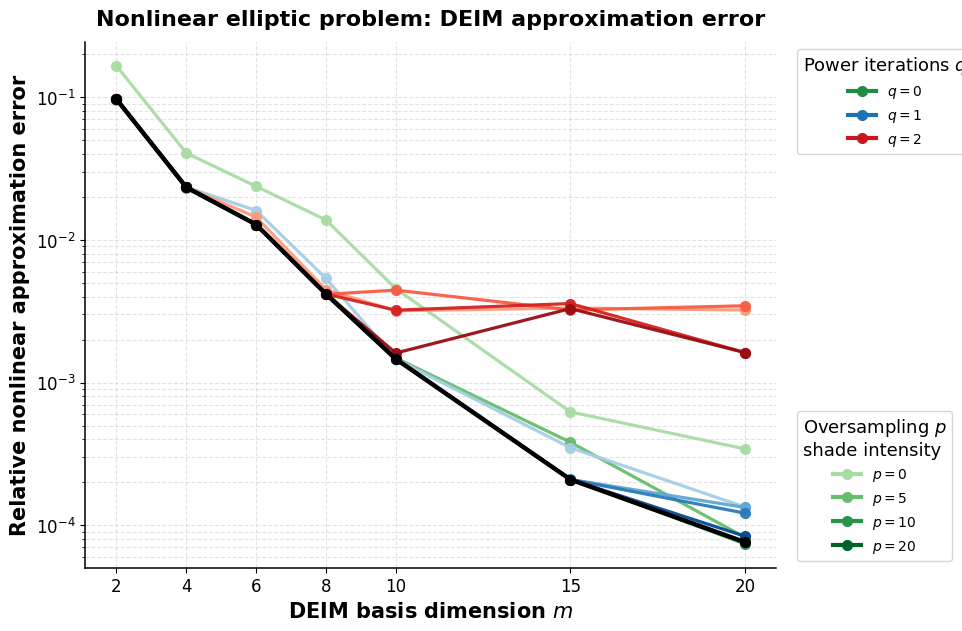

Saved: thesis_figures/elliptic_deim_basis_time.pdf
Saved: thesis_figures/elliptic_deim_basis_time.png


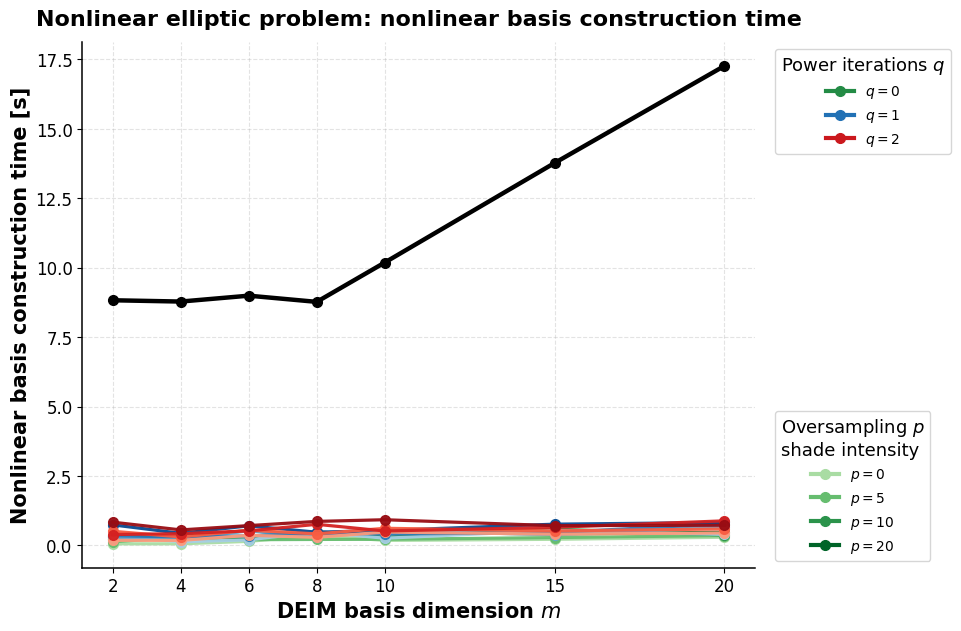

Saved: thesis_figures/elliptic_deim_eval_time.pdf
Saved: thesis_figures/elliptic_deim_eval_time.png


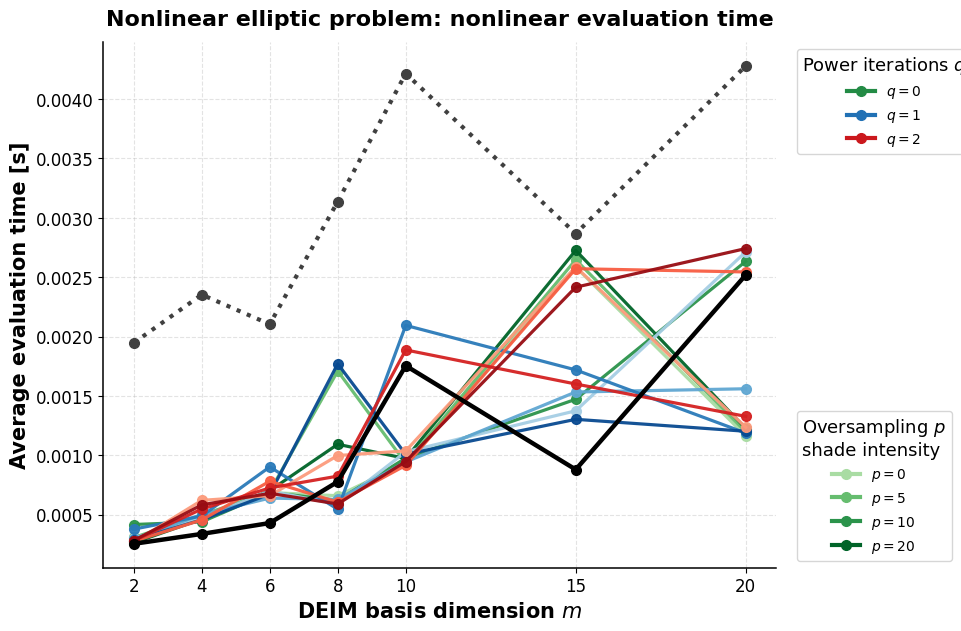

Saved: thesis_figures/elliptic_rsvd_deim_error_heatmap.pdf
Saved: thesis_figures/elliptic_rsvd_deim_error_heatmap.png


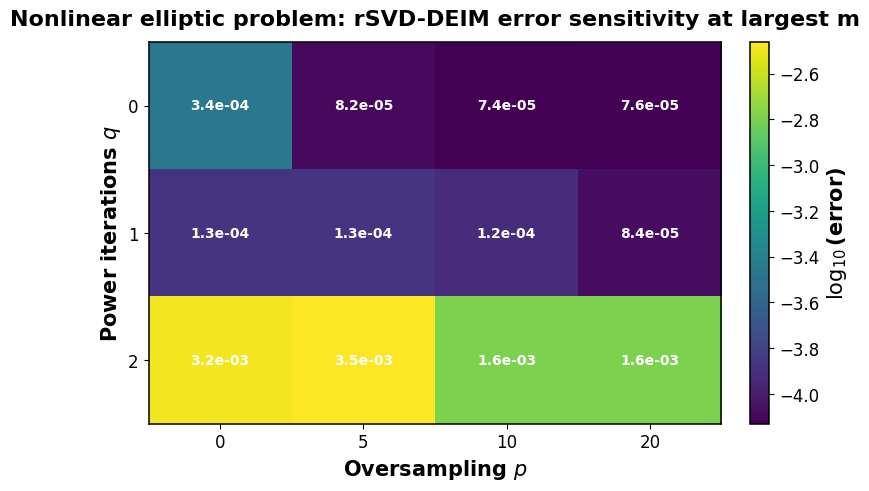

Saved: thesis_figures/elliptic_rsvd_deim_basis_time_heatmap.pdf
Saved: thesis_figures/elliptic_rsvd_deim_basis_time_heatmap.png


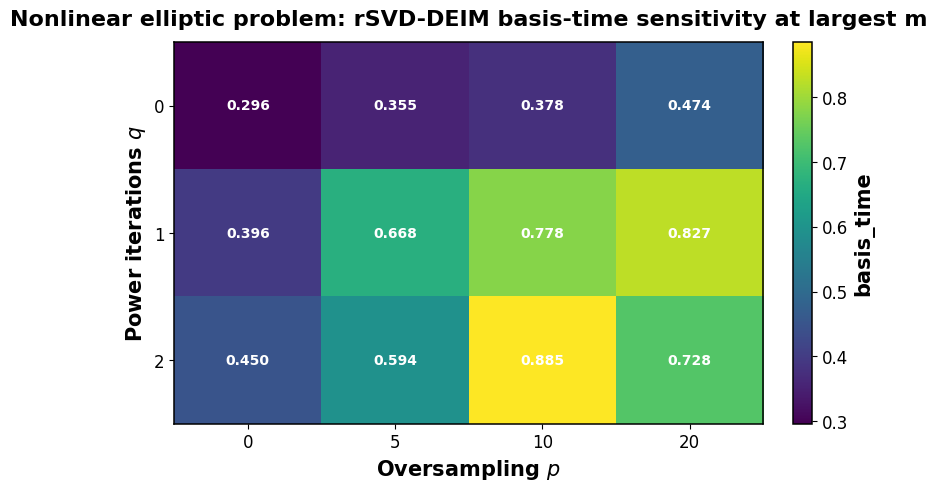

In [64]:
plot_deim_comparison(
    ell_deim_results,
    title_prefix="Nonlinear elliptic problem",
    filename_prefix="elliptic",
)


# 12. Final comparison tables

The following tables summarize:

- POD-SVD and POD-rSVD projection error;
- POD basis construction time;
- POD-DEIM and POD-rSVD-DEIM nonlinear approximation error;
- DEIM nonlinear evaluation time;
- nonlinear basis construction time.

These quantities can be exported and used directly in the report.


In [56]:
import pandas as pd

ac_pod_df = pd.DataFrame(ac_results)
ell_pod_df = pd.DataFrame(ell_results)

ac_deim_df = pd.DataFrame(ac_deim_results)
ell_deim_df = pd.DataFrame(ell_deim_results)

print("Allen-Cahn POD/rSVD-POD results")
display(ac_pod_df)

print("Allen-Cahn DEIM results")
display(ac_deim_df)

print("Elliptic POD/rSVD-POD results")
display(ell_pod_df)

print("Elliptic DEIM results")
display(ell_deim_df)

Allen-Cahn POD/rSVD-POD results


,method,r,p,p_eff,q,error,time,time_std
0,POD-SVD,2,NaN,NaN,NaN,0.002392,1.052421,0.262137
1,POD-rSVD,2,0.0,0.0,0.0,0.009790,0.113441,0.108507
2,POD-rSVD,2,5.0,5.0,0.0,0.002392,0.131327,0.026544
3,POD-rSVD,2,10.0,10.0,0.0,0.002392,0.192085,0.048492
4,POD-rSVD,2,20.0,20.0,0.0,0.002392,0.321136,0.033390
...,...,...,...,...,...,...,...,...
86,POD-rSVD,20,20.0,20.0,1.0,0.000002,0.619889,0.074727
87,POD-rSVD,20,0.0,0.0,2.0,0.000292,0.751672,0.464723
88,POD-rSVD,20,5.0,5.0,2.0,0.000292,0.686086,0.244620
89,POD-rSVD,20,10.0,10.0,2.0,0.000288,2.013614,0.824271


Allen-Cahn DEIM results


,method,basis_method,m,p,p_eff,q,basis_time,basis_time_std,mean_error,std_error,full_time,deim_time,speedup,n_deim_points
0,POD-DEIM,svd,2,NaN,NaN,NaN,3.707178,1.037426,9.580463e-03,3.469447e-18,0.010435,0.000341,30.564096,2
1,POD-DEIM,svd,4,NaN,NaN,NaN,3.898064,0.771545,1.941081e-04,5.421011e-20,0.011040,0.000481,22.956480,4
2,POD-DEIM,svd,6,NaN,NaN,NaN,3.741189,0.797882,7.237663e-06,1.694066e-21,0.010755,0.000602,17.870790,6
3,POD-DEIM,svd,8,NaN,NaN,NaN,3.815404,0.769928,2.050135e-07,2.646978e-23,0.015376,0.001424,10.795506,8
4,POD-DEIM,svd,10,NaN,NaN,NaN,4.147610,0.535361,3.471669e-08,0.000000e+00,0.014048,0.000871,16.136163,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,"p=20, q=2",rsvd,6,20.0,20.0,2.0,0.530229,0.049763,4.442159e-05,1.355253e-20,0.010455,0.000981,10.658370,6
87,"p=20, q=2",rsvd,8,20.0,20.0,2.0,0.522855,0.023534,3.798296e-05,1.355253e-20,0.009498,0.000693,13.709515,8
88,"p=20, q=2",rsvd,10,20.0,20.0,2.0,0.788656,0.419945,4.081207e-05,0.000000e+00,0.012506,0.001192,10.488553,10
89,"p=20, q=2",rsvd,15,20.0,20.0,2.0,0.854992,0.446717,5.271708e-05,6.776264e-21,0.011930,0.001635,7.295869,15


Elliptic POD/rSVD-POD results


,method,r,p,p_eff,q,error,time,time_std
0,POD-SVD,2,NaN,NaN,NaN,0.004343,0.996726,0.240819
1,POD-rSVD,2,0.0,0.0,0.0,0.010993,0.072826,0.003252
2,POD-rSVD,2,5.0,5.0,0.0,0.004348,0.161865,0.031754
3,POD-rSVD,2,10.0,10.0,0.0,0.004343,0.225984,0.062058
4,POD-rSVD,2,20.0,20.0,0.0,0.004343,0.519174,0.225706
...,...,...,...,...,...,...,...,...
86,POD-rSVD,20,20.0,20.0,1.0,0.000003,0.891446,0.459273
87,POD-rSVD,20,0.0,0.0,2.0,0.000234,0.895312,0.529700
88,POD-rSVD,20,5.0,5.0,2.0,0.000235,0.728098,0.046568
89,POD-rSVD,20,10.0,10.0,2.0,0.000239,1.034504,0.475973


Elliptic DEIM results


,method,basis_method,m,p,p_eff,q,basis_time,basis_time_std,mean_error,std_error,full_time,deim_time,speedup,n_deim_points
0,POD-DEIM,svd,2,NaN,NaN,NaN,8.827524,0.490781,0.096902,0.091077,0.001947,0.000255,7.624918,2
1,POD-DEIM,svd,4,NaN,NaN,NaN,8.781171,0.654926,0.023389,0.010187,0.002353,0.000339,6.946565,4
2,POD-DEIM,svd,6,NaN,NaN,NaN,8.992746,0.528743,0.012814,0.005949,0.002104,0.000430,4.889652,6
3,POD-DEIM,svd,8,NaN,NaN,NaN,8.769638,0.471426,0.004176,0.002524,0.003137,0.000778,4.030862,8
4,POD-DEIM,svd,10,NaN,NaN,NaN,10.185166,2.453623,0.001463,0.000564,0.004215,0.001755,2.401850,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,"p=20, q=2",rsvd,6,20.0,20.0,2.0,0.714204,0.303478,0.012814,0.005949,0.002078,0.000680,3.053733,6
87,"p=20, q=2",rsvd,8,20.0,20.0,2.0,0.865173,0.571083,0.004180,0.002524,0.002794,0.000591,4.726231,8
88,"p=20, q=2",rsvd,10,20.0,20.0,2.0,0.925452,0.529848,0.001610,0.000691,0.003004,0.000948,3.166926,10
89,"p=20, q=2",rsvd,15,20.0,20.0,2.0,0.711342,0.096967,0.003300,0.003284,0.003761,0.002416,1.556836,15


# 13. Save figures and tables

Run this cell if you want to export the numerical results as CSV files for your report.

In [65]:
ac_pod_df.to_csv("allen_cahn_pod_svd_rsvd_results.csv", index=False)
ac_deim_df.to_csv("allen_cahn_pod_deim_rsvd_deim_results.csv", index=False)
ell_pod_df.to_csv("elliptic_pod_svd_rsvd_results.csv", index=False)
ell_deim_df.to_csv("elliptic_pod_deim_rsvd_deim_results.csv", index=False)

print("CSV files exported.")
print(f"Figures are stored in: {FIGURE_DIR}/")


CSV files exported.
Figures are stored in: thesis_figures/


# 14. Download thesis figures as a ZIP file

This cell compresses all exported PDF/PNG figures into a single ZIP file and downloads it from Colab. The PDF files are recommended for LaTeX because they keep the figure text sharp.

In [66]:
# Create a ZIP archive containing all thesis figures.
zip_name = "thesis_figures_pdf_png.zip"

with zipfile.ZipFile(zip_name, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(FIGURE_DIR):
        for file in files:
            if file.endswith((".pdf", ".png")):
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, FIGURE_DIR)
                zf.write(full_path, arcname)

print(f"Created {zip_name}")

# In Google Colab this will trigger a browser download.
try:
    from google.colab import files
    files.download(zip_name)
except Exception:
    print("Not running in Colab. Download the ZIP manually from the file browser.")


Created thesis_figures_pdf_png.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>